# Análisis de resultados

Este notebook consolida y analiza los resultados obtenidos durante el entrenamiento y evaluación de los modelos YOLO11 Nano y YOLO11 Small para la detección automática de defectos en placas de circuito impreso.

Los entrenamientos finales fueron ejecutados en Google Colab con GPU, mientras que este análisis se realiza localmente a partir de las métricas y figuras seleccionadas.

## Objetivos

- Comparar el desempeño global de YOLO11 Nano y YOLO11 Small sobre el conjunto de prueba.
- Analizar métricas por clase.
- Evaluar diferencias en precision, recall, mAP@50 y mAP@50:95.
- Revisar matrices de confusión, curvas PR/F1 y ejemplos cualitativos.
- Discutir el compromiso entre desempeño predictivo y costo computacional.

## 1. Importación de librerías y configuración de rutas

Se importan las librerías necesarias y se definen las rutas hacia los archivos de métricas y figuras generados durante la etapa de entrenamiento y evaluación.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Detectar raíz del proyecto
PROJECT_ROOT = Path.cwd().parent

RESULTS_DIR = PROJECT_ROOT / "results"
METRICS_DIR = RESULTS_DIR / "metrics"
FIGURES_DIR = RESULTS_DIR / "figures"

TEST_METRICS_SUMMARY_PATH = METRICS_DIR / "test_metrics_summary.csv"
TEST_METRICS_BY_CLASS_PATH = METRICS_DIR / "test_metrics_by_class.csv"

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Directorio de métricas: {METRICS_DIR}")
print(f"Directorio de figuras: {FIGURES_DIR}")

Raíz del proyecto: c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo
Directorio de métricas: c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\results\metrics
Directorio de figuras: c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\results\figures


In [3]:
assert METRICS_DIR.exists(), "No se encontró results/metrics."
assert FIGURES_DIR.exists(), "No se encontró results/figures."
assert TEST_METRICS_SUMMARY_PATH.exists(), "No se encontró test_metrics_summary.csv."
assert TEST_METRICS_BY_CLASS_PATH.exists(), "No se encontró test_metrics_by_class.csv."

print("Rutas validadas correctamente.")

Rutas validadas correctamente.


## 2. Comparación global en conjunto de prueba

Se analizan las métricas globales obtenidas por YOLO11 Nano y YOLO11 Small sobre el conjunto `test`, reservado exclusivamente para la evaluación final.

Las métricas consideradas son:

- **Precision:** proporción de detecciones realizadas por el modelo que son correctas.
- **Recall:** proporción de defectos reales que fueron detectados por el modelo.
- **mAP@50:** promedio de precisión media considerando un umbral de IoU de 0,50.
- **mAP@50:95:** promedio de precisión media considerando múltiples umbrales de IoU entre 0,50 y 0,95.

En el contexto de inspección de calidad, el *recall* resulta especialmente relevante, ya que un falso negativo implica que un defecto real no fue detectado.

In [4]:
# Leer métricas globales de test
df_test_metrics = pd.read_csv(TEST_METRICS_SUMMARY_PATH)

df_test_metrics

,model,precision,recall,mAP50,mAP50_95
0,YOLO11n,0.922457,0.906759,0.953771,0.685606
1,YOLO11s,0.938966,0.914269,0.961891,0.723329


In [5]:
# Formatear métricas en porcentaje
df_test_metrics_display = df_test_metrics.copy()

metric_columns = [
    "precision",
    "recall",
    "mAP50",
    "mAP50_95",
]

for column in metric_columns:
    df_test_metrics_display[column] = (
        df_test_metrics_display[column] * 100
    ).round(2)

df_test_metrics_display

,model,precision,recall,mAP50,mAP50_95
0,YOLO11n,92.25,90.68,95.38,68.56
1,YOLO11s,93.90,91.43,96.19,72.33


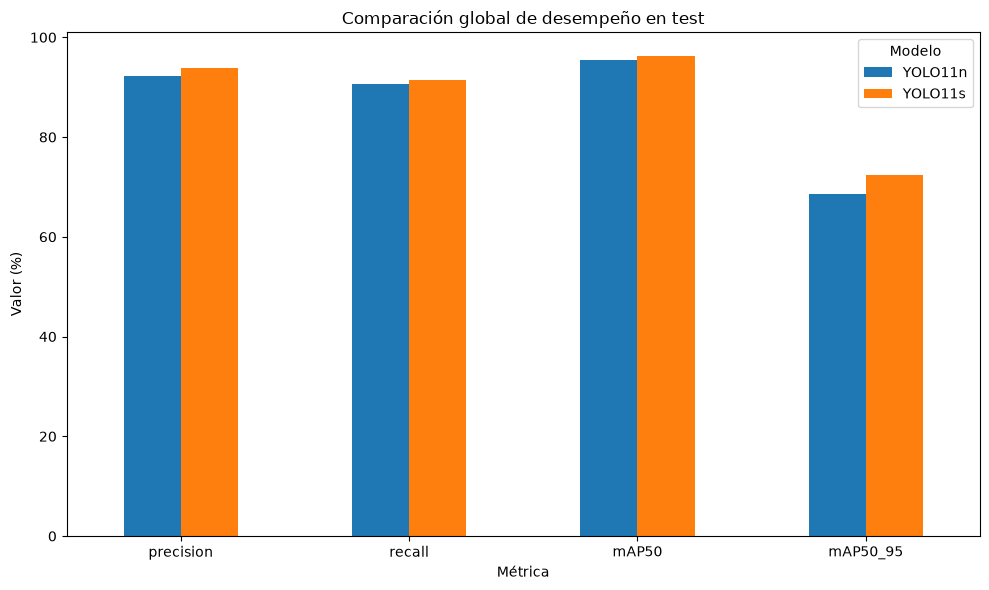

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = df_test_metrics.set_index("model")[metric_columns] * 100

plot_data.T.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Comparación global de desempeño en test")
ax.set_xlabel("Métrica")
ax.set_ylabel("Valor (%)")
ax.legend(title="Modelo")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 2.1 Interpretación de resultados globales

Los resultados sobre el conjunto de prueba muestran que ambos modelos alcanzan un desempeño elevado en la detección de defectos en PCB.

YOLO11 Nano obtiene una precision de 92,25 %, recall de 90,68 %, mAP@50 de 95,38 % y mAP@50:95 de 68,56 %. Por su parte, YOLO11 Small mejora estos valores, alcanzando una precision de 93,90 %, recall de 91,43 %, mAP@50 de 96,19 % y mAP@50:95 de 72,33 %.

La mejora más relevante se observa en mAP@50:95, donde YOLO11 Small supera a YOLO11 Nano por aproximadamente 3,77 puntos porcentuales. Esta métrica es más exigente que mAP@50, ya que evalúa la calidad de la localización considerando múltiples umbrales de IoU. Por lo tanto, la diferencia sugiere que YOLO11 Small no sólo detecta correctamente más defectos, sino que también logra una localización más precisa de las bounding boxes.

En términos de recall, YOLO11 Small también obtiene un mejor desempeño, con una mejora de aproximadamente 0,75 puntos porcentuales. Si bien la diferencia es menor, resulta relevante en un contexto de inspección de calidad, donde los falsos negativos implican defectos reales no detectados.

En síntesis, YOLO11 Small presenta el mejor desempeño global, aunque la magnitud de la mejora debe analizarse junto con su mayor costo computacional.

In [7]:
# Calcular diferencia de YOLO11s respecto de YOLO11n
metrics_nano = df_test_metrics[
    df_test_metrics["model"] == "YOLO11n"
].iloc[0]

metrics_small = df_test_metrics[
    df_test_metrics["model"] == "YOLO11s"
].iloc[0]

comparison_rows = []

for metric in metric_columns:
    nano_value = metrics_nano[metric]
    small_value = metrics_small[metric]
    
    comparison_rows.append({
        "metric": metric,
        "YOLO11n (%)": nano_value * 100,
        "YOLO11s (%)": small_value * 100,
        "difference_pp": (small_value - nano_value) * 100,
        "relative_improvement_%": (
            (small_value - nano_value) / nano_value
        ) * 100,
    })

df_global_comparison = pd.DataFrame(comparison_rows)

df_global_comparison[
    [
        "YOLO11n (%)",
        "YOLO11s (%)",
        "difference_pp",
        "relative_improvement_%",
    ]
] = df_global_comparison[
    [
        "YOLO11n (%)",
        "YOLO11s (%)",
        "difference_pp",
        "relative_improvement_%",
    ]
].round(2)

df_global_comparison

,metric,YOLO11n (%),YOLO11s (%),difference_pp,relative_improvement_%
0,precision,92.25,93.90,1.65,1.79
1,recall,90.68,91.43,0.75,0.83
2,mAP50,95.38,96.19,0.81,0.85
3,mAP50_95,68.56,72.33,3.77,5.50


## 3. Comparación de métricas por clase

Además de analizar las métricas globales, se evalúa el desempeño de cada modelo para cada categoría de defecto.

Este análisis permite identificar si las mejoras observadas en YOLO11 Small son uniformes entre clases o si se concentran en determinados tipos de defectos. También permite detectar categorías particularmente difíciles para ambos modelos.

In [8]:
# Leer métricas por clase
df_class_metrics = pd.read_csv(TEST_METRICS_BY_CLASS_PATH)

df_class_metrics

,model,class_id,class_name,precision,recall,mAP50,mAP50_95
0,YOLO11n,0,open,0.973386,0.832486,0.960576,0.611563
1,YOLO11n,1,short,0.700790,0.864017,0.863129,0.542447
2,YOLO11n,2,mousebite,0.960880,0.922128,0.975155,0.667924
3,YOLO11n,3,spur,0.962924,0.914127,0.960720,0.675406
4,YOLO11n,4,copper,0.952324,0.965517,0.978986,0.825264
5,YOLO11n,5,pin-hole,0.984440,0.942277,0.984061,0.791032
6,YOLO11s,0,open,0.938077,0.942514,0.966499,0.623456
7,YOLO11s,1,short,0.813637,0.864017,0.898452,0.594920
8,YOLO11s,2,mousebite,0.971478,0.930034,0.971534,0.699904
9,YOLO11s,3,spur,0.980151,0.886128,0.967215,0.714028


In [9]:
df_class_metrics_display = df_class_metrics.copy()

for column in metric_columns:
    df_class_metrics_display[column] = (
        df_class_metrics_display[column] * 100
    ).round(2)

df_class_metrics_display

,model,class_id,class_name,precision,recall,mAP50,mAP50_95
0,YOLO11n,0,open,97.34,83.25,96.06,61.16
1,YOLO11n,1,short,70.08,86.40,86.31,54.24
2,YOLO11n,2,mousebite,96.09,92.21,97.52,66.79
3,YOLO11n,3,spur,96.29,91.41,96.07,67.54
4,YOLO11n,4,copper,95.23,96.55,97.90,82.53
5,YOLO11n,5,pin-hole,98.44,94.23,98.41,79.10
6,YOLO11s,0,open,93.81,94.25,96.65,62.35
7,YOLO11s,1,short,81.36,86.40,89.85,59.49
8,YOLO11s,2,mousebite,97.15,93.00,97.15,69.99
9,YOLO11s,3,spur,98.02,88.61,96.72,71.40


In [10]:
df_map_by_class = (
    df_class_metrics
    .pivot(
        index="class_name",
        columns="model",
        values="mAP50_95"
    )
    .reset_index()
)

df_map_by_class["difference_pp"] = (
    df_map_by_class["YOLO11s"] - df_map_by_class["YOLO11n"]
) * 100

df_map_by_class["YOLO11n"] = (
    df_map_by_class["YOLO11n"] * 100
).round(2)

df_map_by_class["YOLO11s"] = (
    df_map_by_class["YOLO11s"] * 100
).round(2)

df_map_by_class["difference_pp"] = (
    df_map_by_class["difference_pp"]
).round(2)

df_map_by_class.sort_values(
    "difference_pp",
    ascending=False
)

model,class_name,YOLO11n,YOLO11s,difference_pp
0,copper,82.53,87.89,5.37
4,short,54.24,59.49,5.25
5,spur,67.54,71.40,3.86
3,pin-hole,79.10,82.87,3.77
1,mousebite,66.79,69.99,3.20
2,open,61.16,62.35,1.19


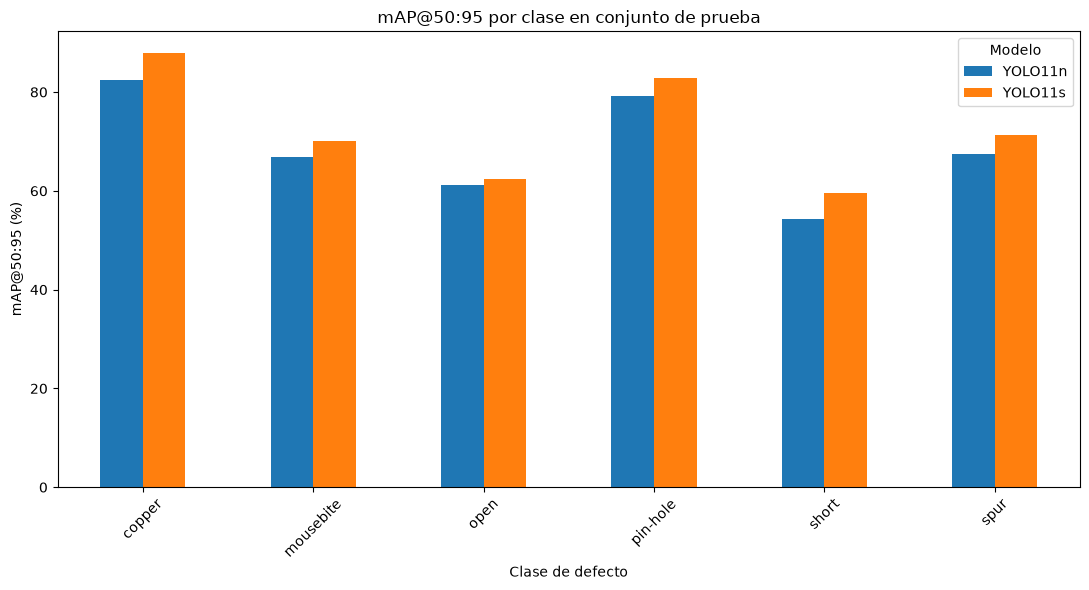

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_data = (
    df_class_metrics
    .pivot(
        index="class_name",
        columns="model",
        values="mAP50_95"
    ) * 100
)

plot_data.plot(
    kind="bar",
    ax=ax
)

ax.set_title("mAP@50:95 por clase en conjunto de prueba")
ax.set_xlabel("Clase de defecto")
ax.set_ylabel("mAP@50:95 (%)")
ax.legend(title="Modelo")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 3.1 Interpretación de métricas por clase

El análisis por clase muestra que YOLO11 Small supera a YOLO11 Nano en las seis categorías de defectos al considerar la métrica mAP@50:95.

Las mayores mejoras se observan en las clases `copper` y `short`, con incrementos de aproximadamente 5,37 y 5,25 puntos porcentuales, respectivamente. También se observan mejoras relevantes en `spur`, `pin-hole` y `mousebite`, con incrementos entre 3,20 y 3,86 puntos porcentuales. La clase `open` presenta la menor diferencia entre modelos, con una mejora de 1,19 puntos porcentuales.

En términos absolutos, las clases con mejor desempeño son `copper` y `pin-hole`, especialmente para YOLO11 Small, que alcanza valores de mAP@50:95 de 87,89 % y 82,87 %, respectivamente.

Por el contrario, las clases más desafiantes son `short`, `open` y `mousebite`. En particular, `short` presenta el menor desempeño absoluto en ambos modelos, aunque también muestra una de las mayores mejoras al pasar de YOLO11 Nano a YOLO11 Small. Esto sugiere que la mayor capacidad representacional del modelo Small contribuye a mejorar la detección y localización de algunas clases más difíciles, aunque no elimina completamente la brecha de desempeño.

Estos resultados refuerzan la conclusión de que YOLO11 Small ofrece un mejor desempeño predictivo, no sólo a nivel global sino también en el análisis por categoría. Sin embargo, la decisión final entre ambos modelos debe considerar también el costo computacional asociado.

## 4. Análisis de precision y recall por clase

En problemas de inspección visual, el *recall* tiene una importancia particular porque mide la proporción de defectos reales que el modelo logra detectar. Un bajo recall implica una mayor probabilidad de falsos negativos, es decir, defectos que podrían pasar desapercibidos.

La *precision*, por otro lado, permite analizar la confiabilidad de las detecciones realizadas. Una baja precision implica una mayor cantidad de falsos positivos, lo que puede generar revisiones innecesarias o rechazos incorrectos.

In [12]:
df_recall_by_class = (
    df_class_metrics
    .pivot(
        index="class_name",
        columns="model",
        values="recall"
    )
    .reset_index()
)

df_recall_by_class["difference_pp"] = (
    df_recall_by_class["YOLO11s"] - df_recall_by_class["YOLO11n"]
) * 100

df_recall_by_class["YOLO11n"] = (
    df_recall_by_class["YOLO11n"] * 100
).round(2)

df_recall_by_class["YOLO11s"] = (
    df_recall_by_class["YOLO11s"] * 100
).round(2)

df_recall_by_class["difference_pp"] = (
    df_recall_by_class["difference_pp"]
).round(2)

df_recall_by_class.sort_values(
    "difference_pp",
    ascending=False
)

model,class_name,YOLO11n,YOLO11s,difference_pp
2,open,83.25,94.25,11.00
1,mousebite,92.21,93.00,0.79
4,short,86.40,86.40,0.00
3,pin-hole,94.23,93.40,-0.82
5,spur,91.41,88.61,-2.80
0,copper,96.55,92.89,-3.66


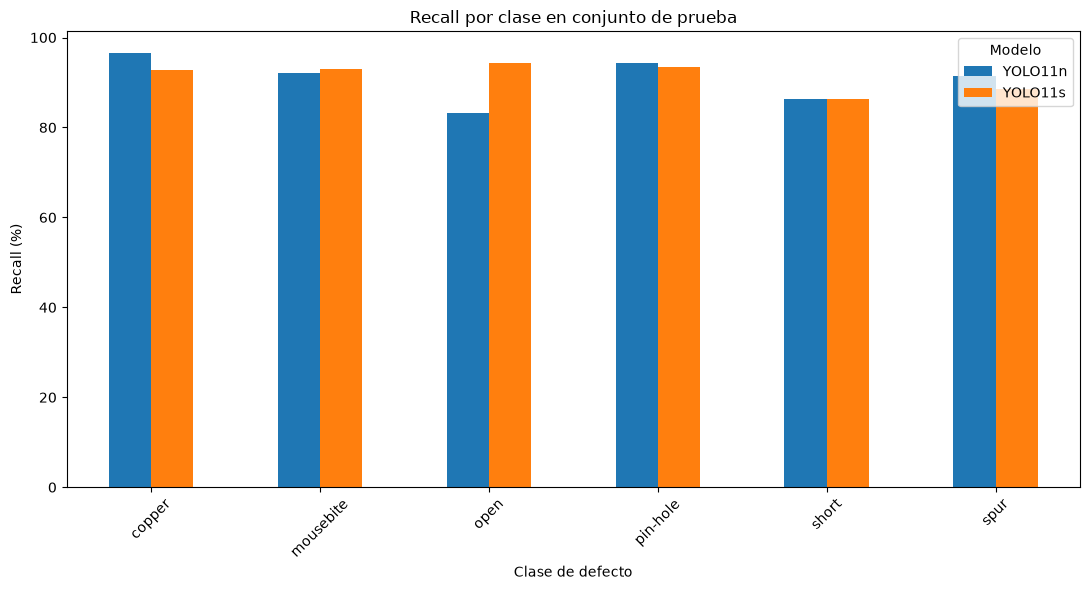

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_data = (
    df_class_metrics
    .pivot(
        index="class_name",
        columns="model",
        values="recall"
    ) * 100
)

plot_data.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Recall por clase en conjunto de prueba")
ax.set_xlabel("Clase de defecto")
ax.set_ylabel("Recall (%)")
ax.legend(title="Modelo")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [14]:
df_precision_by_class = (
    df_class_metrics
    .pivot(
        index="class_name",
        columns="model",
        values="precision"
    )
    .reset_index()
)

df_precision_by_class["difference_pp"] = (
    df_precision_by_class["YOLO11s"] - df_precision_by_class["YOLO11n"]
) * 100

df_precision_by_class["YOLO11n"] = (
    df_precision_by_class["YOLO11n"] * 100
).round(2)

df_precision_by_class["YOLO11s"] = (
    df_precision_by_class["YOLO11s"] * 100
).round(2)

df_precision_by_class["difference_pp"] = (
    df_precision_by_class["difference_pp"]
).round(2)

df_precision_by_class.sort_values(
    "difference_pp",
    ascending=False
)

model,class_name,YOLO11n,YOLO11s,difference_pp
4,short,70.08,81.36,11.28
0,copper,95.23,97.07,1.84
5,spur,96.29,98.02,1.72
1,mousebite,96.09,97.15,1.06
3,pin-hole,98.44,95.97,-2.47
2,open,97.34,93.81,-3.53


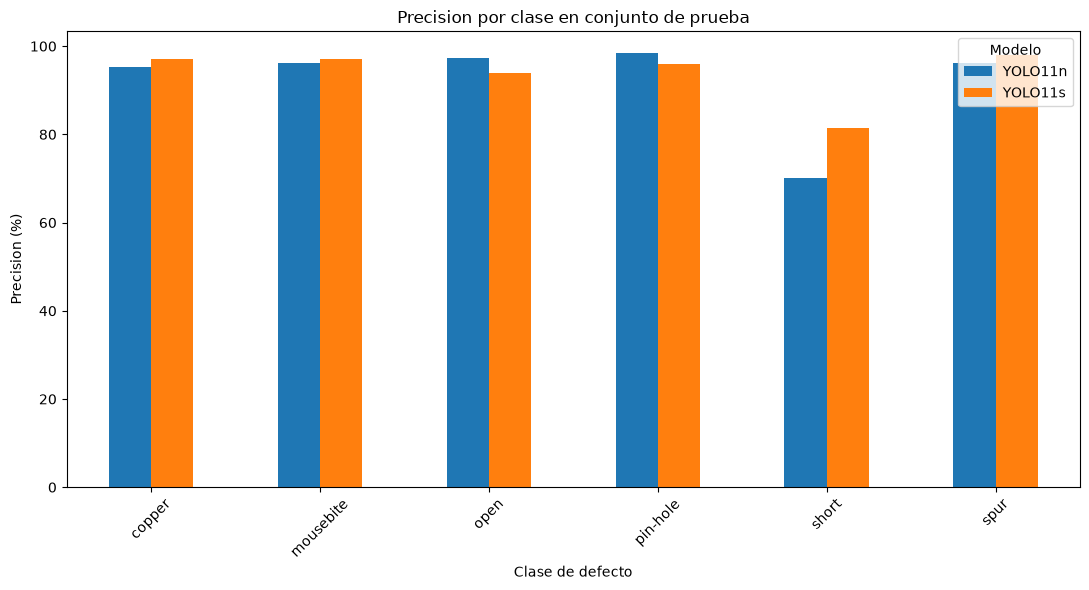

In [15]:
fig, ax = plt.subplots(figsize=(11, 6))

plot_data = (
    df_class_metrics
    .pivot(
        index="class_name",
        columns="model",
        values="precision"
    ) * 100
)

plot_data.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Precision por clase en conjunto de prueba")
ax.set_xlabel("Clase de defecto")
ax.set_ylabel("Precision (%)")
ax.legend(title="Modelo")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 4.1 Interpretación de precision y recall por clase

El análisis de precision y recall muestra diferencias más específicas entre los modelos.

En términos de **recall**, YOLO11 Small mejora especialmente en la clase `open`, donde pasa de 83,25 % a 94,25 %, con una mejora de 11 puntos porcentuales. También presenta una leve mejora en `mousebite`. Sin embargo, en otras clases el recall se mantiene igual o disminuye levemente respecto de YOLO11 Nano, como ocurre en `copper`, `spur` y `pin-hole`.

Esto indica que YOLO11 Small no incrementa la capacidad de detección de todos los tipos de defectos por igual. Su mejora global de recall se explica principalmente por el fuerte aumento en la detección de la clase `open`.

En términos de **precision**, YOLO11 Small mejora de manera marcada en la clase `short`, pasando de 70,08 % a 81,36 %, con una mejora de 11,28 puntos porcentuales. También presenta mejoras menores en `copper`, `spur` y `mousebite`. Por otro lado, disminuye la precision en `open` y `pin-hole`.

Este comportamiento sugiere que el modelo Small modifica el balance entre falsos positivos y falsos negativos según la clase. En particular, para `open`, YOLO11 Small detecta una mayor proporción de defectos reales, pero con una menor precision, lo que puede implicar un aumento relativo de falsos positivos. En cambio, para `short`, la mejora principal aparece en precision, lo que indica detecciones más confiables para esa categoría.

Por lo tanto, aunque YOLO11 Small obtiene mejores métricas globales y mayor mAP@50:95 en todas las clases, la mejora no debe interpretarse como uniforme en todos los tipos de error. La elección del modelo dependerá del criterio funcional prioritario: maximizar detección de defectos reales, minimizar falsas alarmas o lograr una mejor localización general.

Desde una perspectiva de control de calidad, el incremento de recall en `open` resulta especialmente relevante, dado que un defecto no detectado puede avanzar en el proceso productivo. Sin embargo, la caída de recall en `copper`, `spur` y `pin-hole` sugiere que la selección del modelo no debería basarse únicamente en la métrica global, sino también en la criticidad relativa de cada tipo de defecto.

En este caso, YOLO11 Small continúa siendo el modelo con mejor desempeño general, especialmente por su mayor mAP@50:95, pero el análisis por clase permite identificar oportunidades de mejora futura, como ajuste de umbrales de confianza por clase, análisis de falsos positivos y falsos negativos, o entrenamiento con mayor cantidad de ejemplos representativos.

## 5. Análisis visual de matrices de confusión y curvas

Además de las métricas tabulares, se revisan las visualizaciones generadas por Ultralytics durante la evaluación sobre el conjunto de prueba.

Las matrices de confusión permiten observar errores de clasificación entre clases, mientras que las curvas PR, F1, Precision y Recall permiten analizar el comportamiento del modelo frente a distintos umbrales de confianza.

YOLO11n - Matriz de confusión normalizada


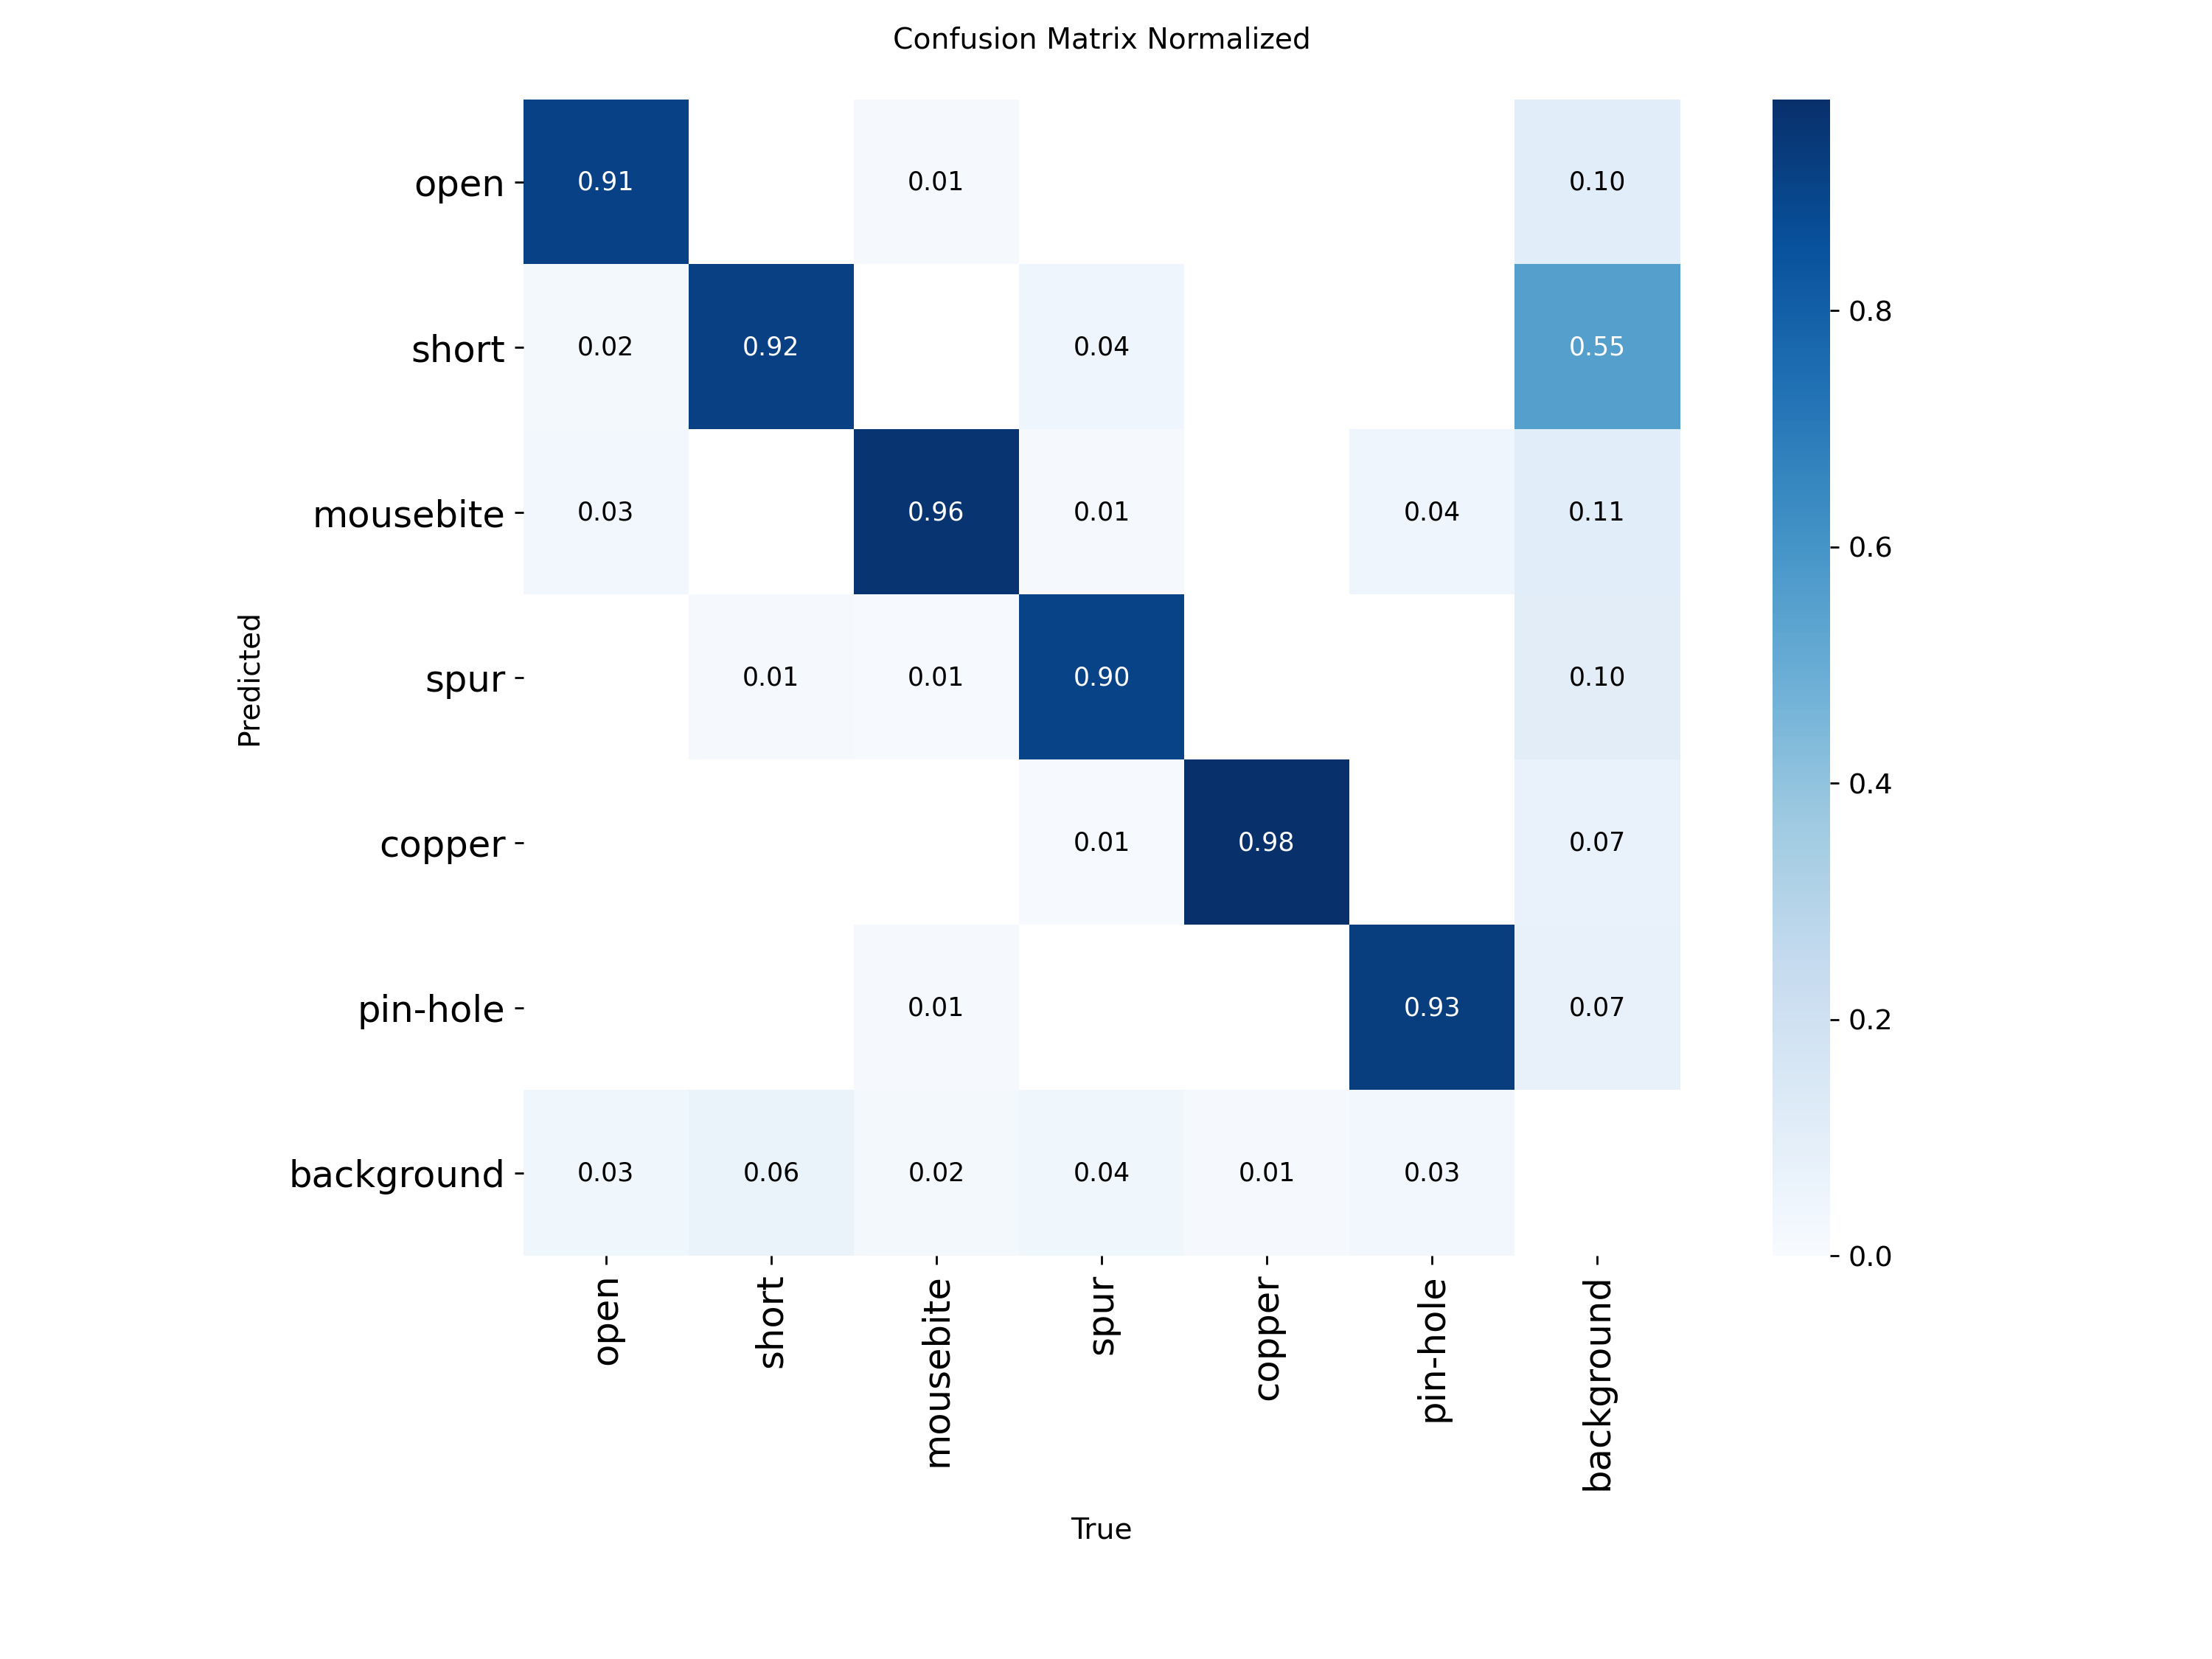

YOLO11s - Matriz de confusión normalizada


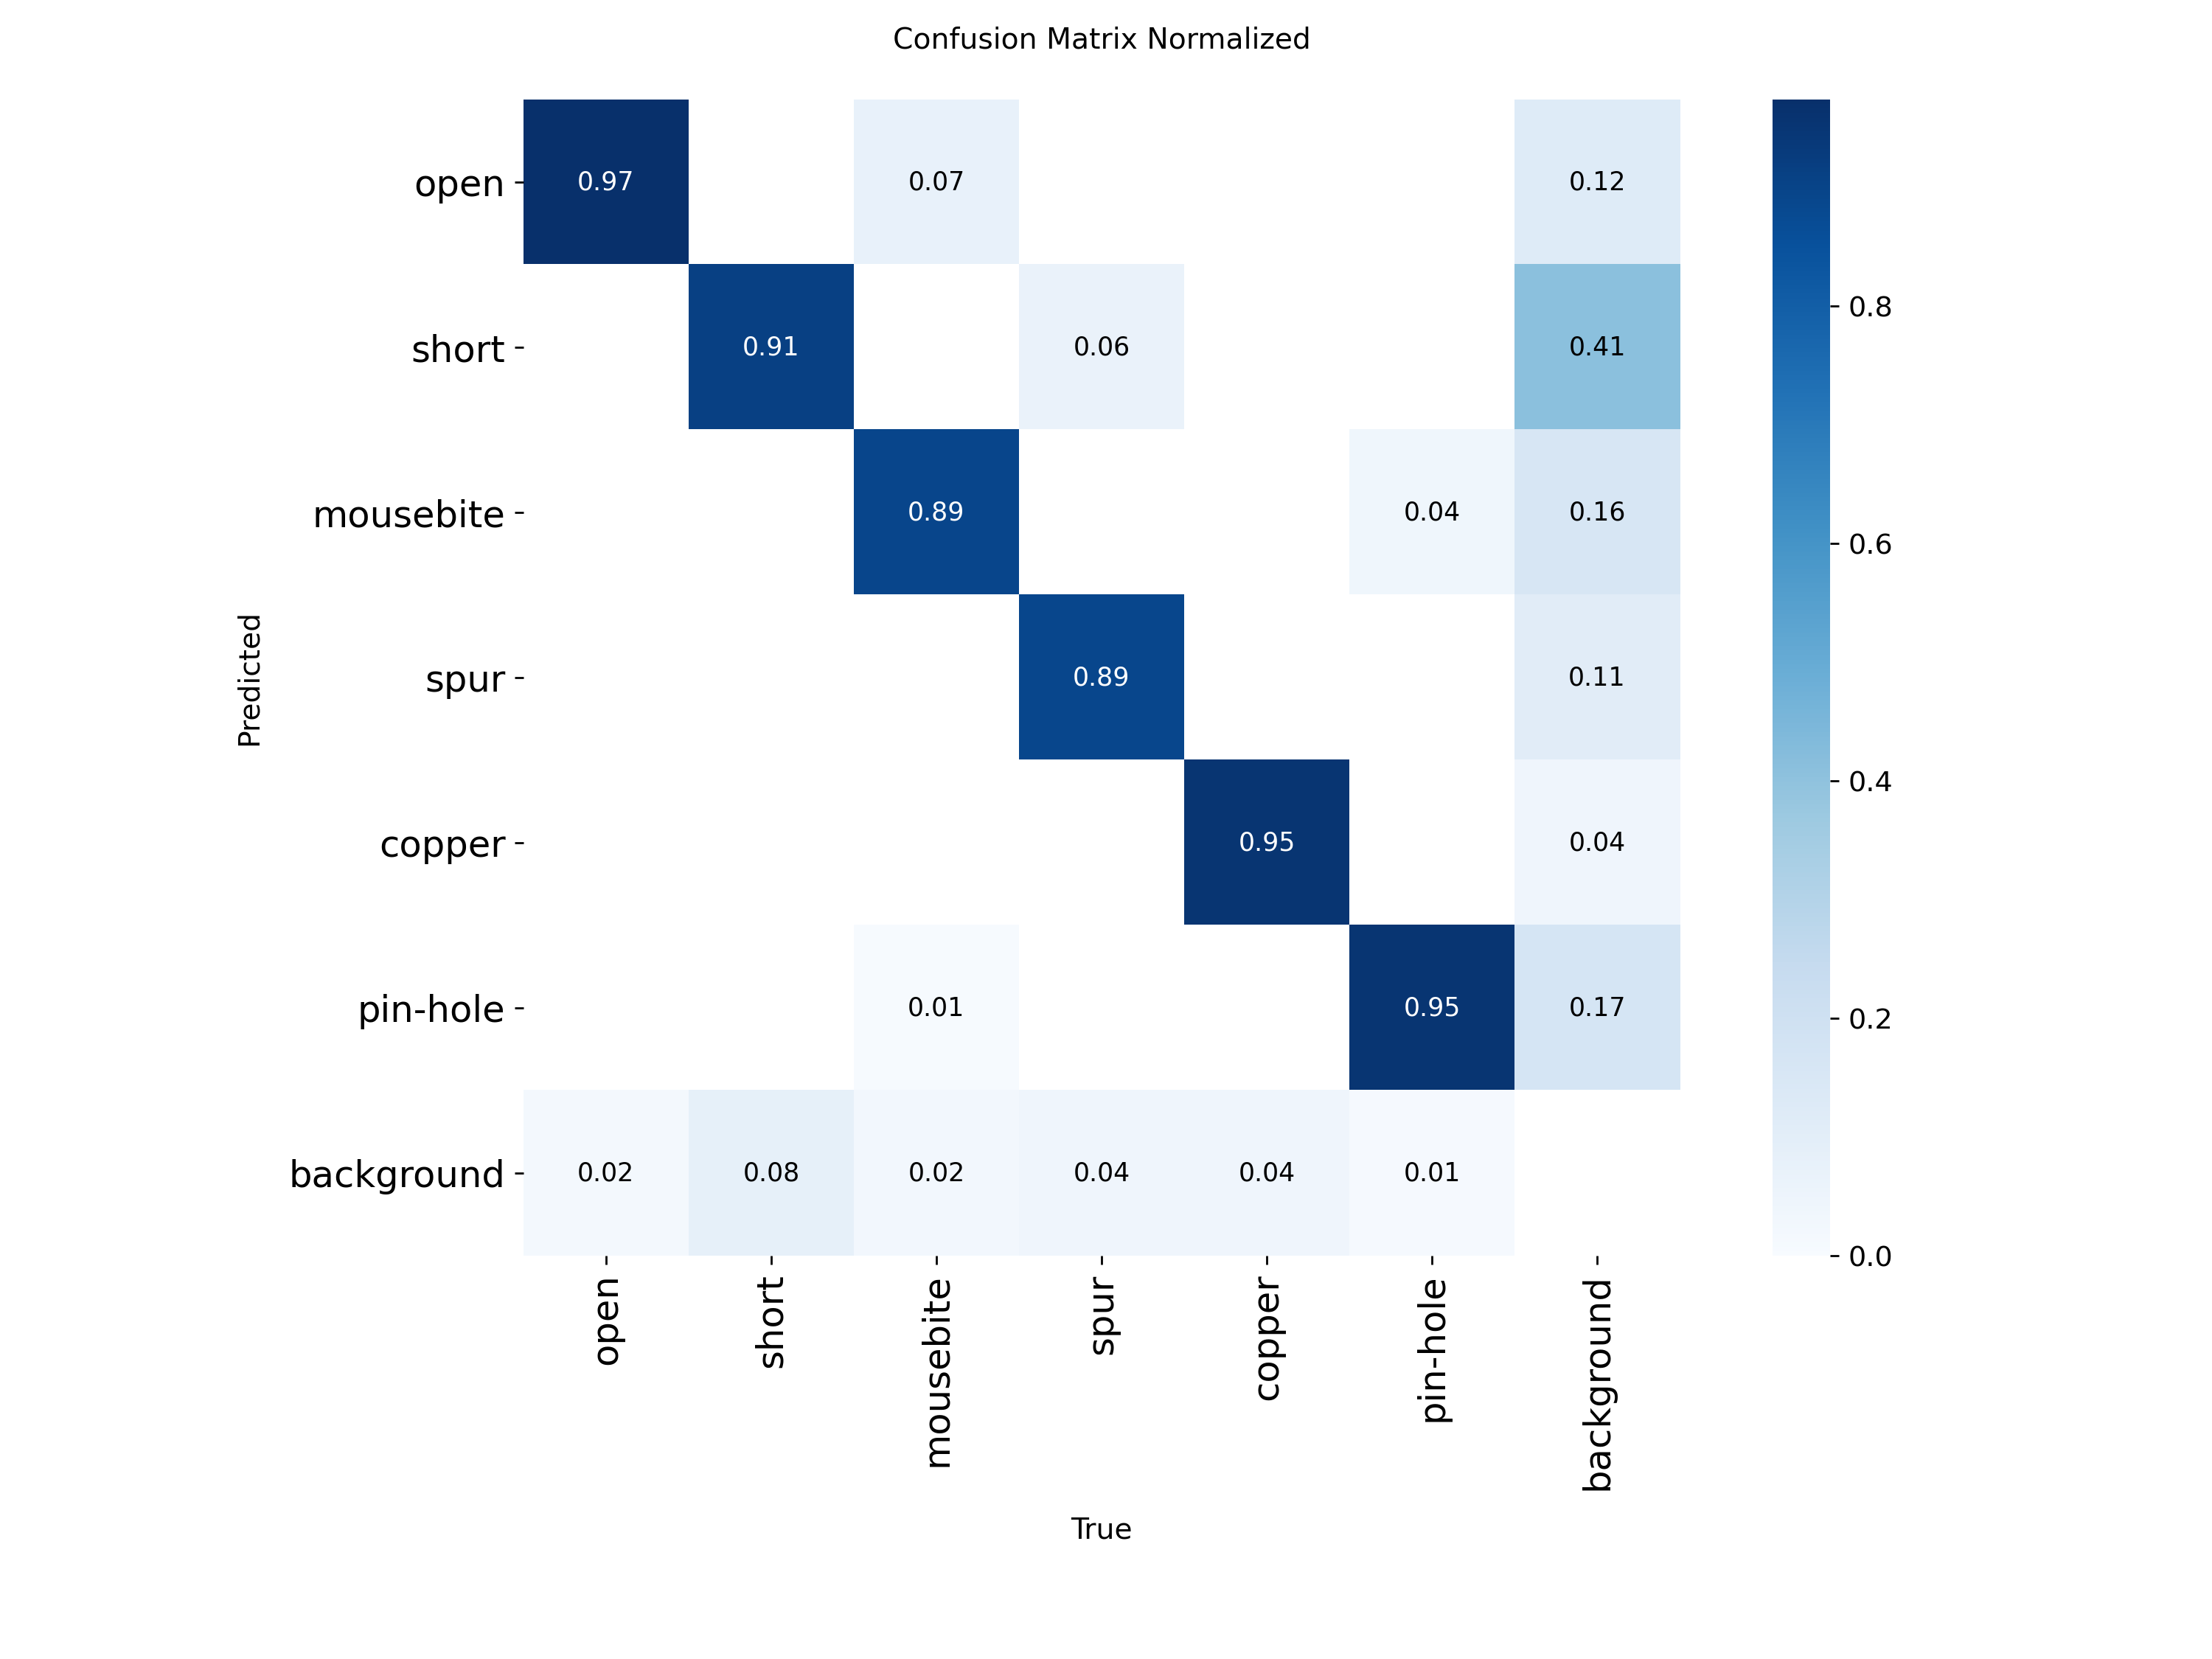

In [16]:
from IPython.display import Image, display

figure_files = {
    "YOLO11n - Matriz de confusión normalizada": "yolo11n_test_confusion_matrix_normalized.png",
    "YOLO11s - Matriz de confusión normalizada": "yolo11s_test_confusion_matrix_normalized.png",
}

for title, filename in figure_files.items():
    print(title)
    display(Image(filename=str(FIGURES_DIR / filename)))

YOLO11n - Curva Precision-Recall


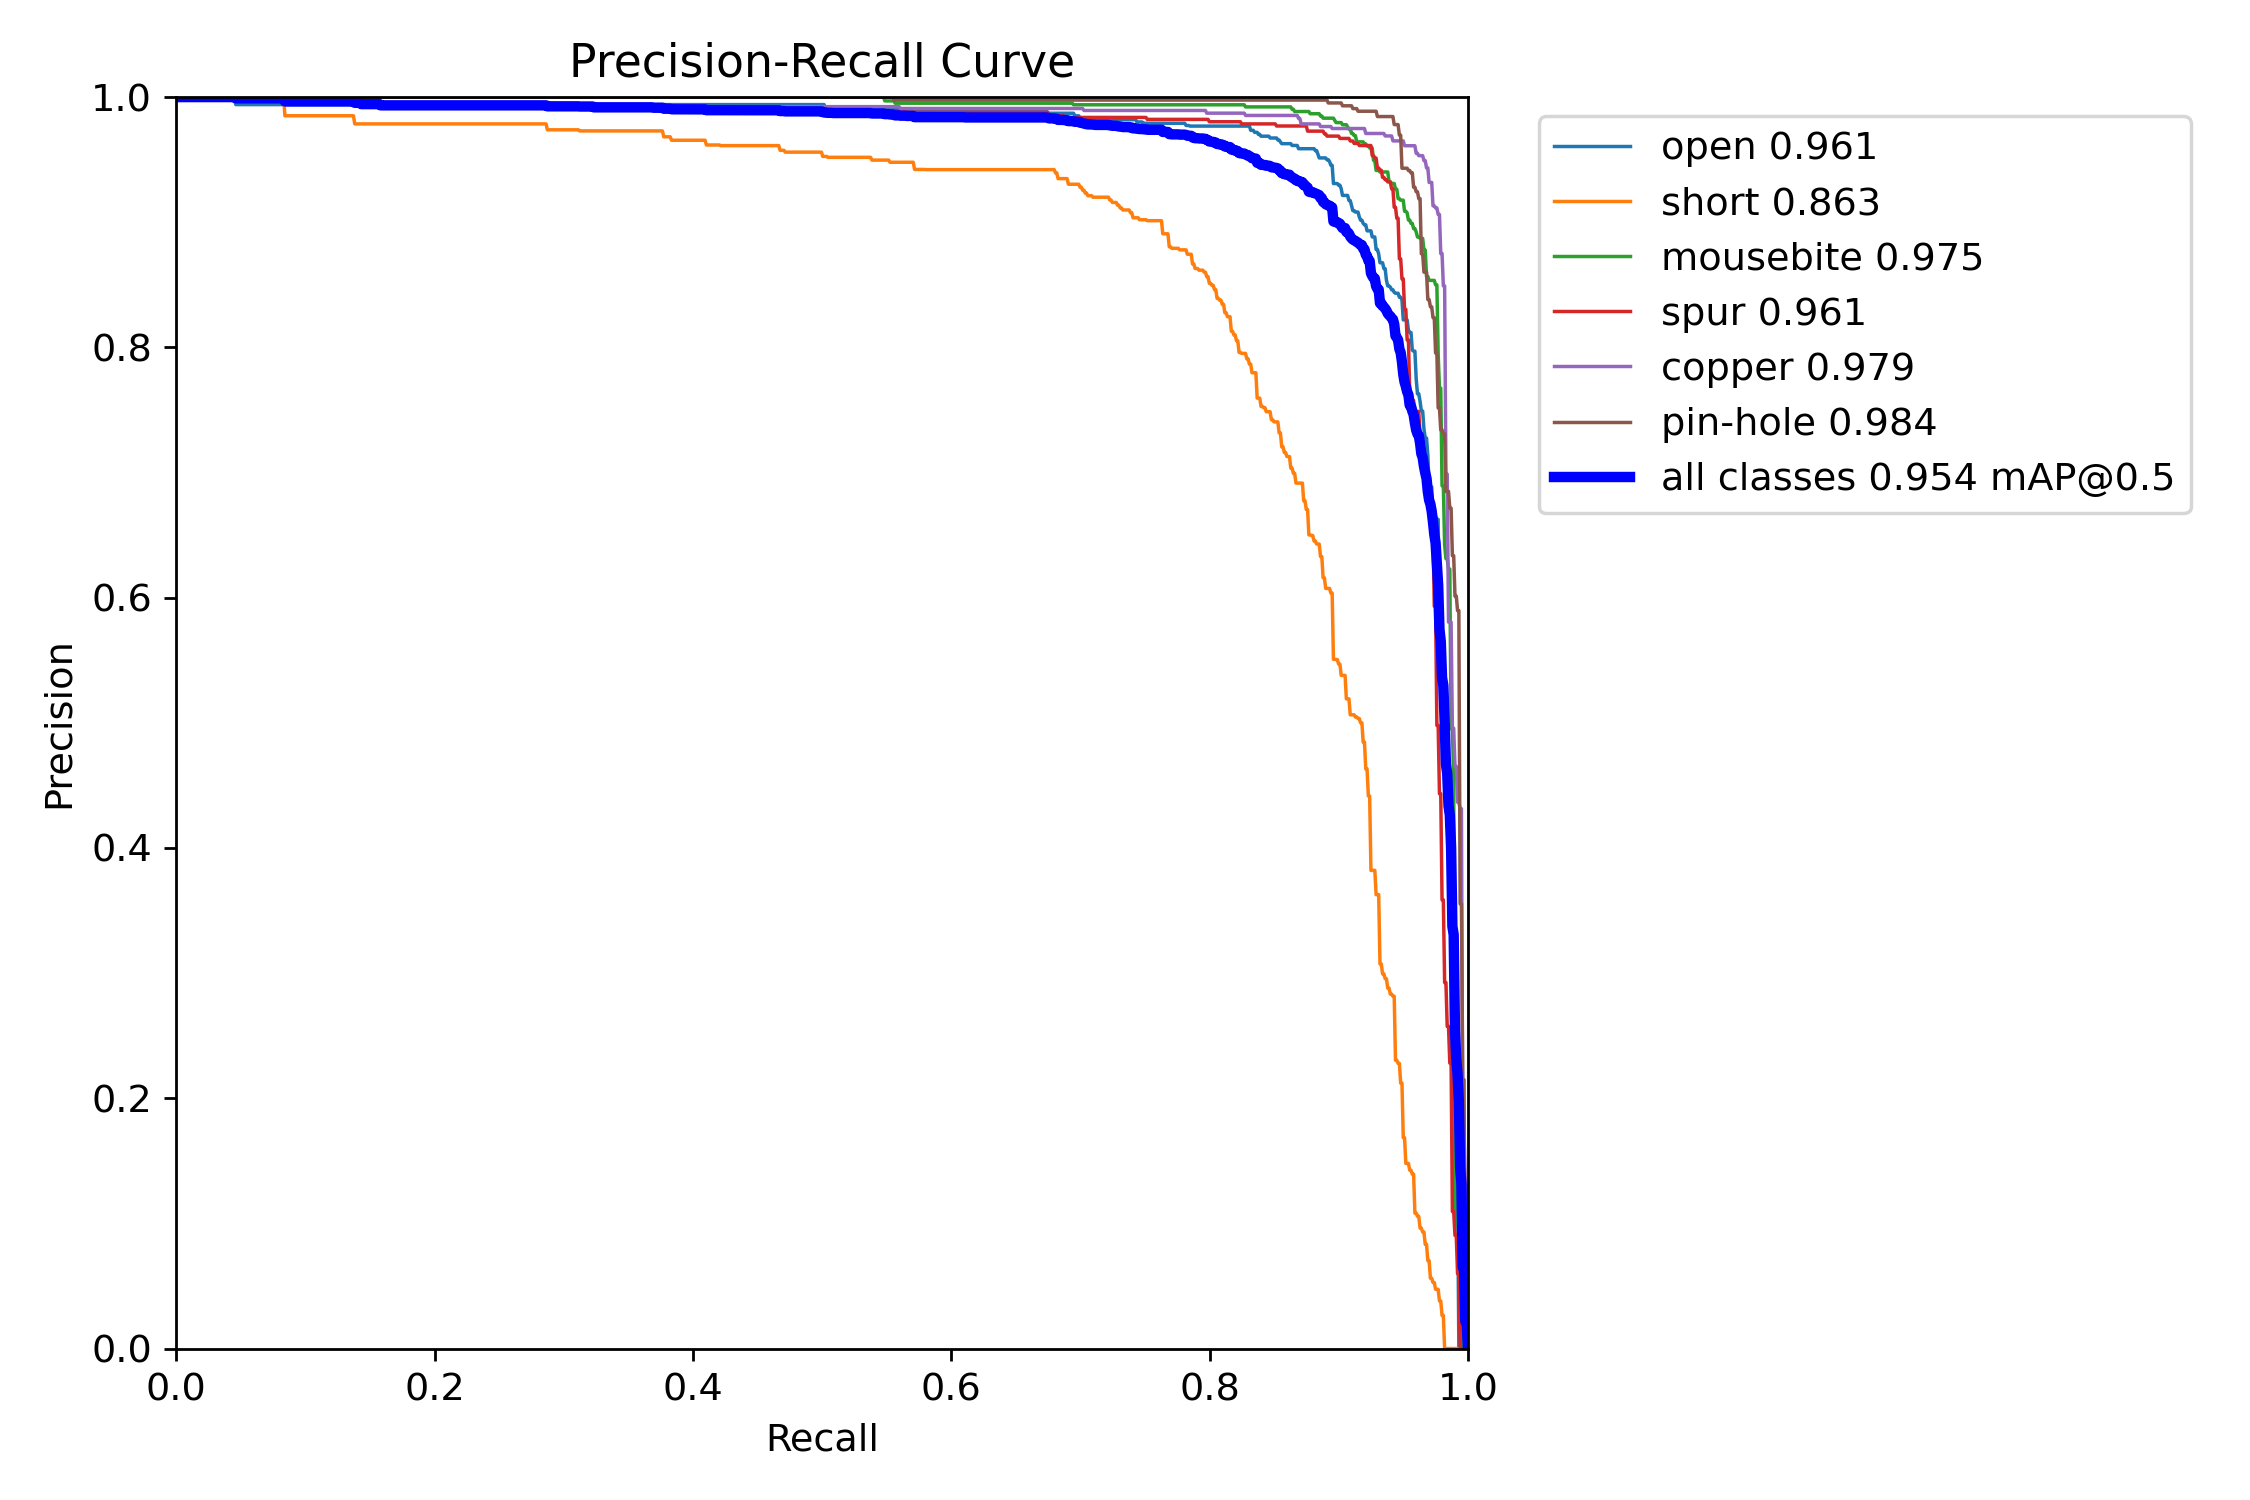

YOLO11s - Curva Precision-Recall


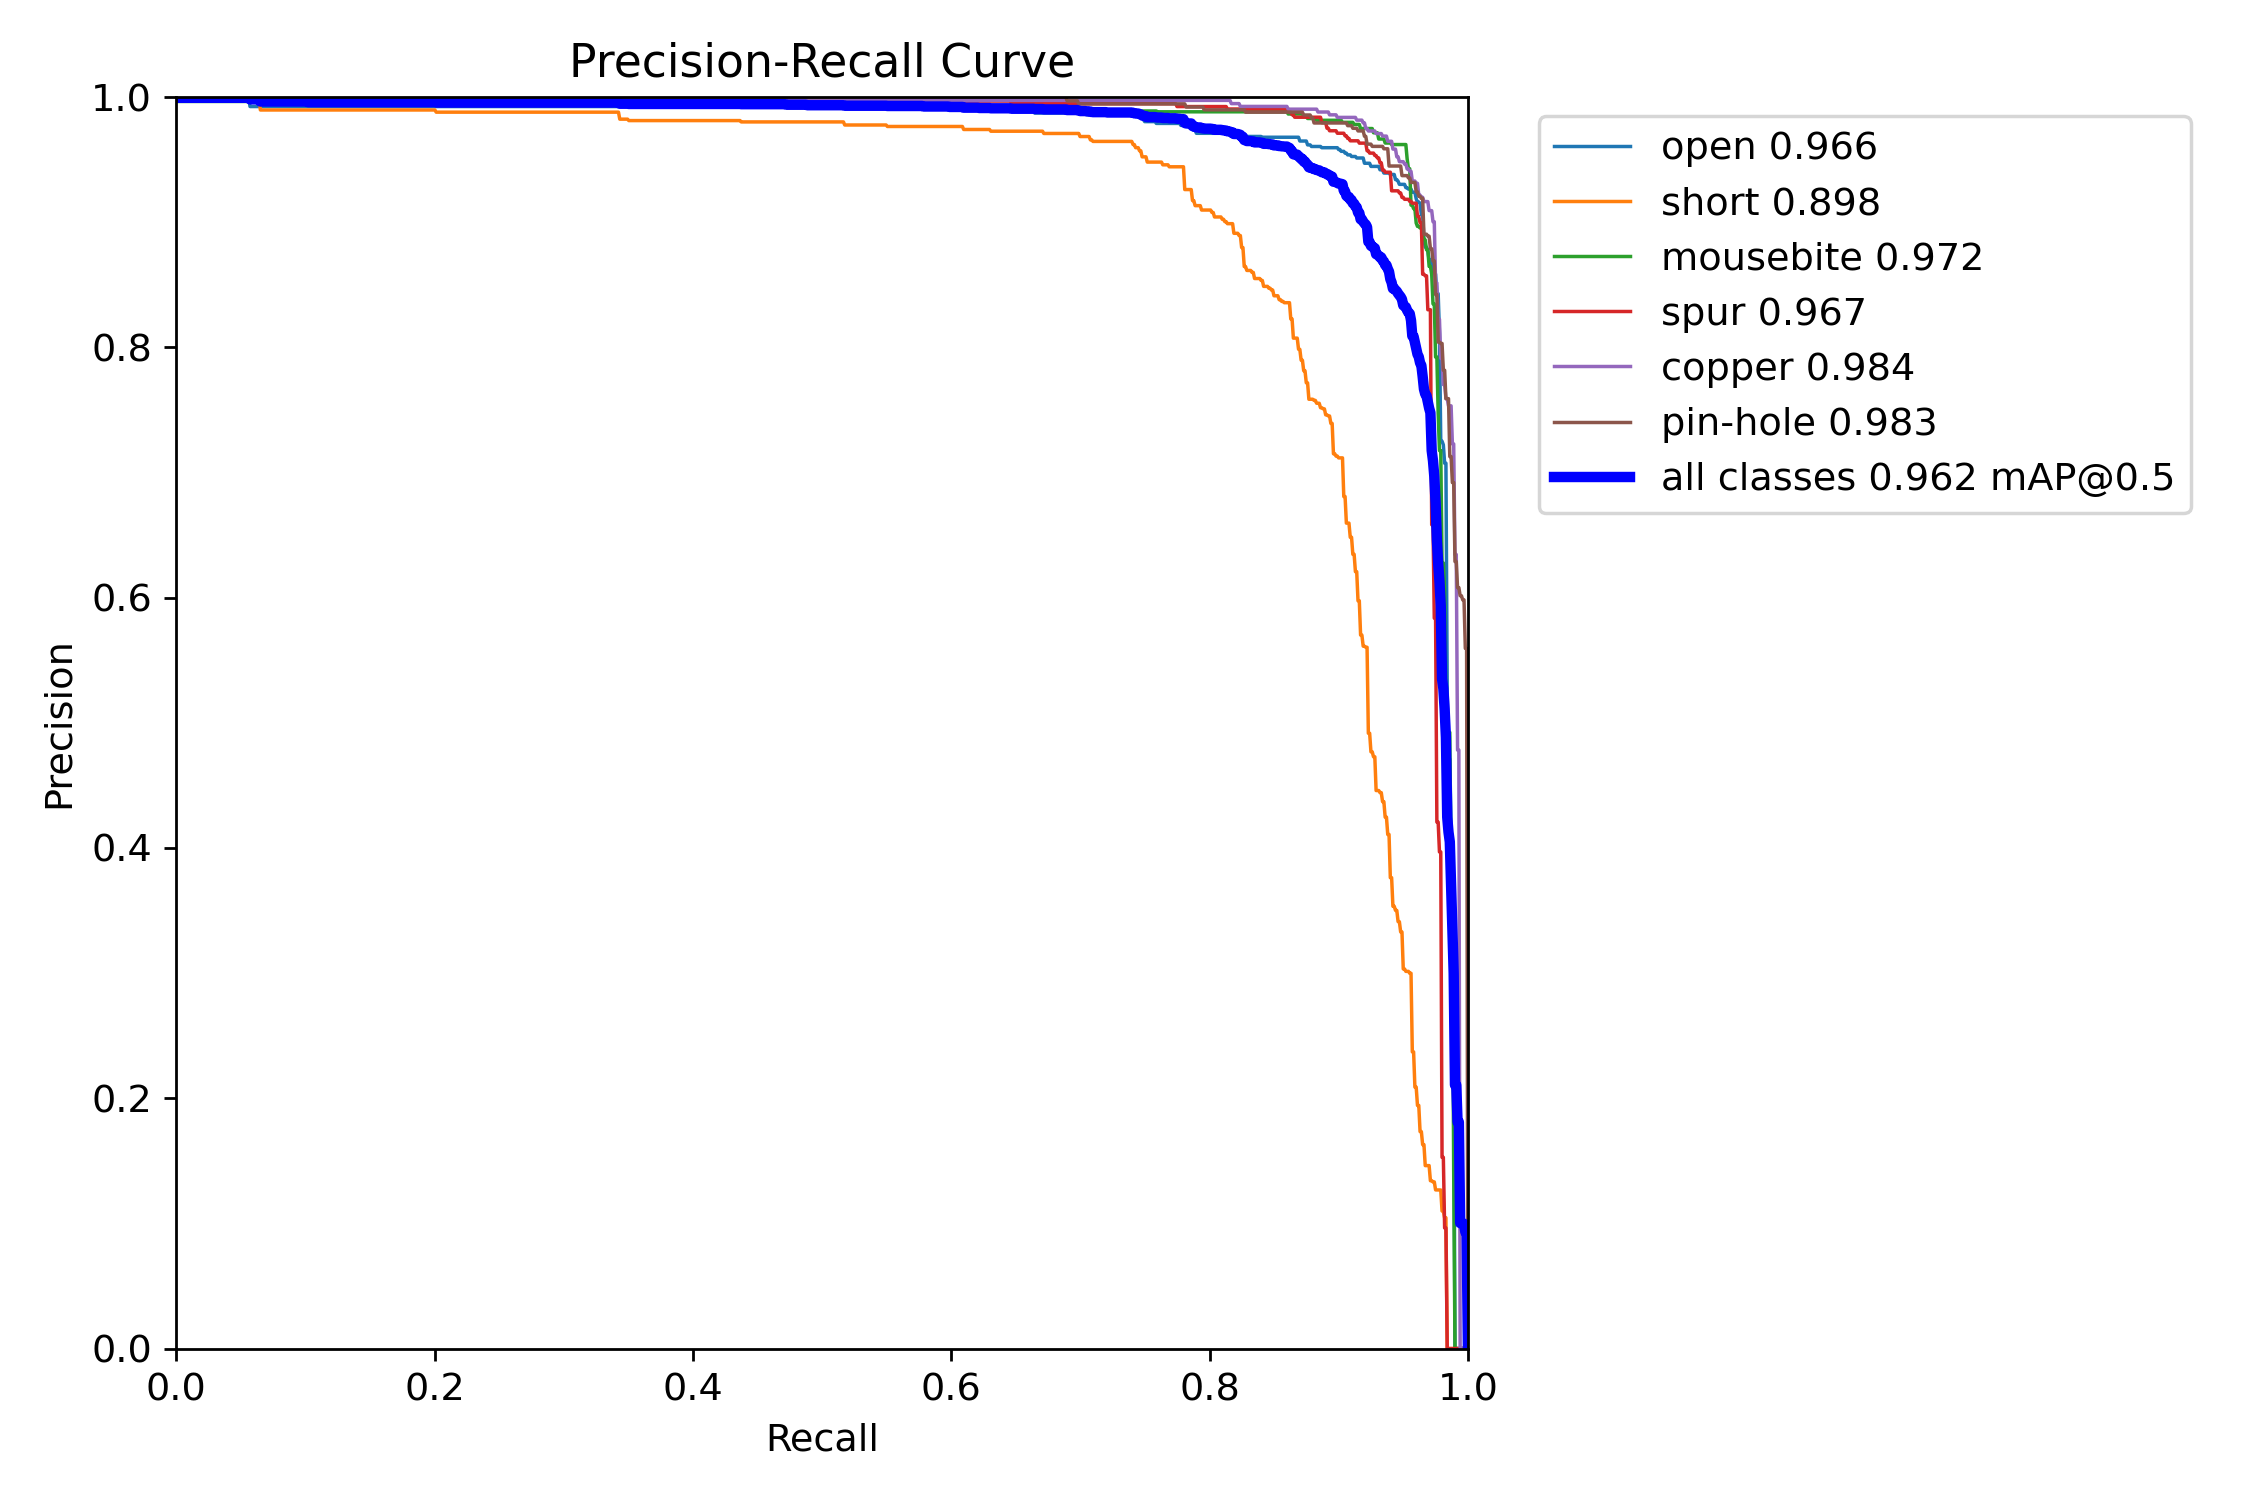

In [17]:
figure_files = {
    "YOLO11n - Curva Precision-Recall": "yolo11n_test_BoxPR_curve.png",
    "YOLO11s - Curva Precision-Recall": "yolo11s_test_BoxPR_curve.png",
}

for title, filename in figure_files.items():
    print(title)
    display(Image(filename=str(FIGURES_DIR / filename)))

### 5.1 Interpretación de matrices de confusión

Las matrices de confusión normalizadas muestran un buen desempeño general para ambos modelos, con valores elevados en la diagonal principal para la mayoría de las clases. Esto indica que, cuando los modelos realizan detecciones, tienden a asignar correctamente la categoría del defecto.

En YOLO11 Nano se observan valores altos de clasificación correcta para `open`, `short`, `mousebite`, `spur`, `copper` y `pin-hole`. No obstante, aparece una proporción relevante de errores asociados al fondo, especialmente en la clase `short`, donde se observa una relación importante con la columna de `background`. Esto sugiere la presencia de falsos positivos o detecciones que el modelo asocia incorrectamente con regiones sin defecto.

En YOLO11 Small se mantiene una diagonal principal elevada y se observa una mejora clara para `open`, consistente con el aumento de recall observado previamente. También se reduce la relación de `short` con `background` respecto de YOLO11 Nano, lo cual acompaña la mejora de precision para esta clase.

Sin embargo, el modelo Small no mejora uniformemente todos los casos. En algunas clases aparecen leves incrementos de confusión con fondo, lo cual es consistente con el análisis de precision y recall por clase. Esto refuerza la idea de que la mejora global de YOLO11 Small no implica una reducción homogénea de todos los tipos de error, sino un cambio en el balance entre falsos positivos, falsos negativos y calidad de localización.

### 5.2 Interpretación de curvas Precision-Recall

Las curvas Precision-Recall muestran un desempeño elevado para ambos modelos, con curvas cercanas al extremo superior derecho del gráfico en la mayoría de las clases. Esto indica que los modelos logran mantener niveles altos de precision incluso a valores elevados de recall.

En YOLO11 Nano, el mAP@50 global alcanza aproximadamente 0,954. Las clases `pin-hole`, `copper`, `mousebite`, `open` y `spur` presentan curvas muy favorables. La clase `short`, en cambio, muestra una caída más temprana de precision a medida que aumenta el recall, lo que confirma que se trata de una de las categorías más desafiantes para el modelo.

En YOLO11 Small, el mAP@50 global aumenta a aproximadamente 0,962. La curva global se mantiene ligeramente por encima de la observada para YOLO11 Nano, y se observa una mejora en la clase `short`, cuyo AP@50 pasa de aproximadamente 0,863 a 0,898. Este resultado es consistente con la mejora de precision observada para dicha clase en la tabla de métricas.

En conjunto, las curvas PR refuerzan la conclusión de que YOLO11 Small ofrece un mejor desempeño global, aunque la diferencia entre modelos es moderada. La principal ganancia parece estar asociada a una mejor calidad de detección y localización en ciertas clases difíciles, más que a una mejora radical en todas las categorías.

En síntesis, la evidencia visual es consistente con las métricas mostradas en las tablas: ambos modelos logran detectar defectos con alto desempeño, pero YOLO11 Small presenta una ventaja general, especialmente en mAP@50:95 y en algunas clases problemáticas como `short` y `open`. No obstante, las matrices de confusión y el análisis por clase muestran que el desempeño no es uniforme entre categorías, por lo que futuras mejoras deberían focalizarse en el análisis de errores por tipo de defecto y en el ajuste de umbrales de confianza por clase.

## 6. Análisis cualitativo de predicciones

Además de las métricas cuantitativas, se revisan ejemplos visuales de predicciones generadas sobre el conjunto de prueba.

Este análisis permite observar de manera directa la capacidad de los modelos para localizar defectos en imágenes reales del dataset y complementar la interpretación de las métricas globales y por clase.

YOLO11n - Ejemplo de predicciones en test


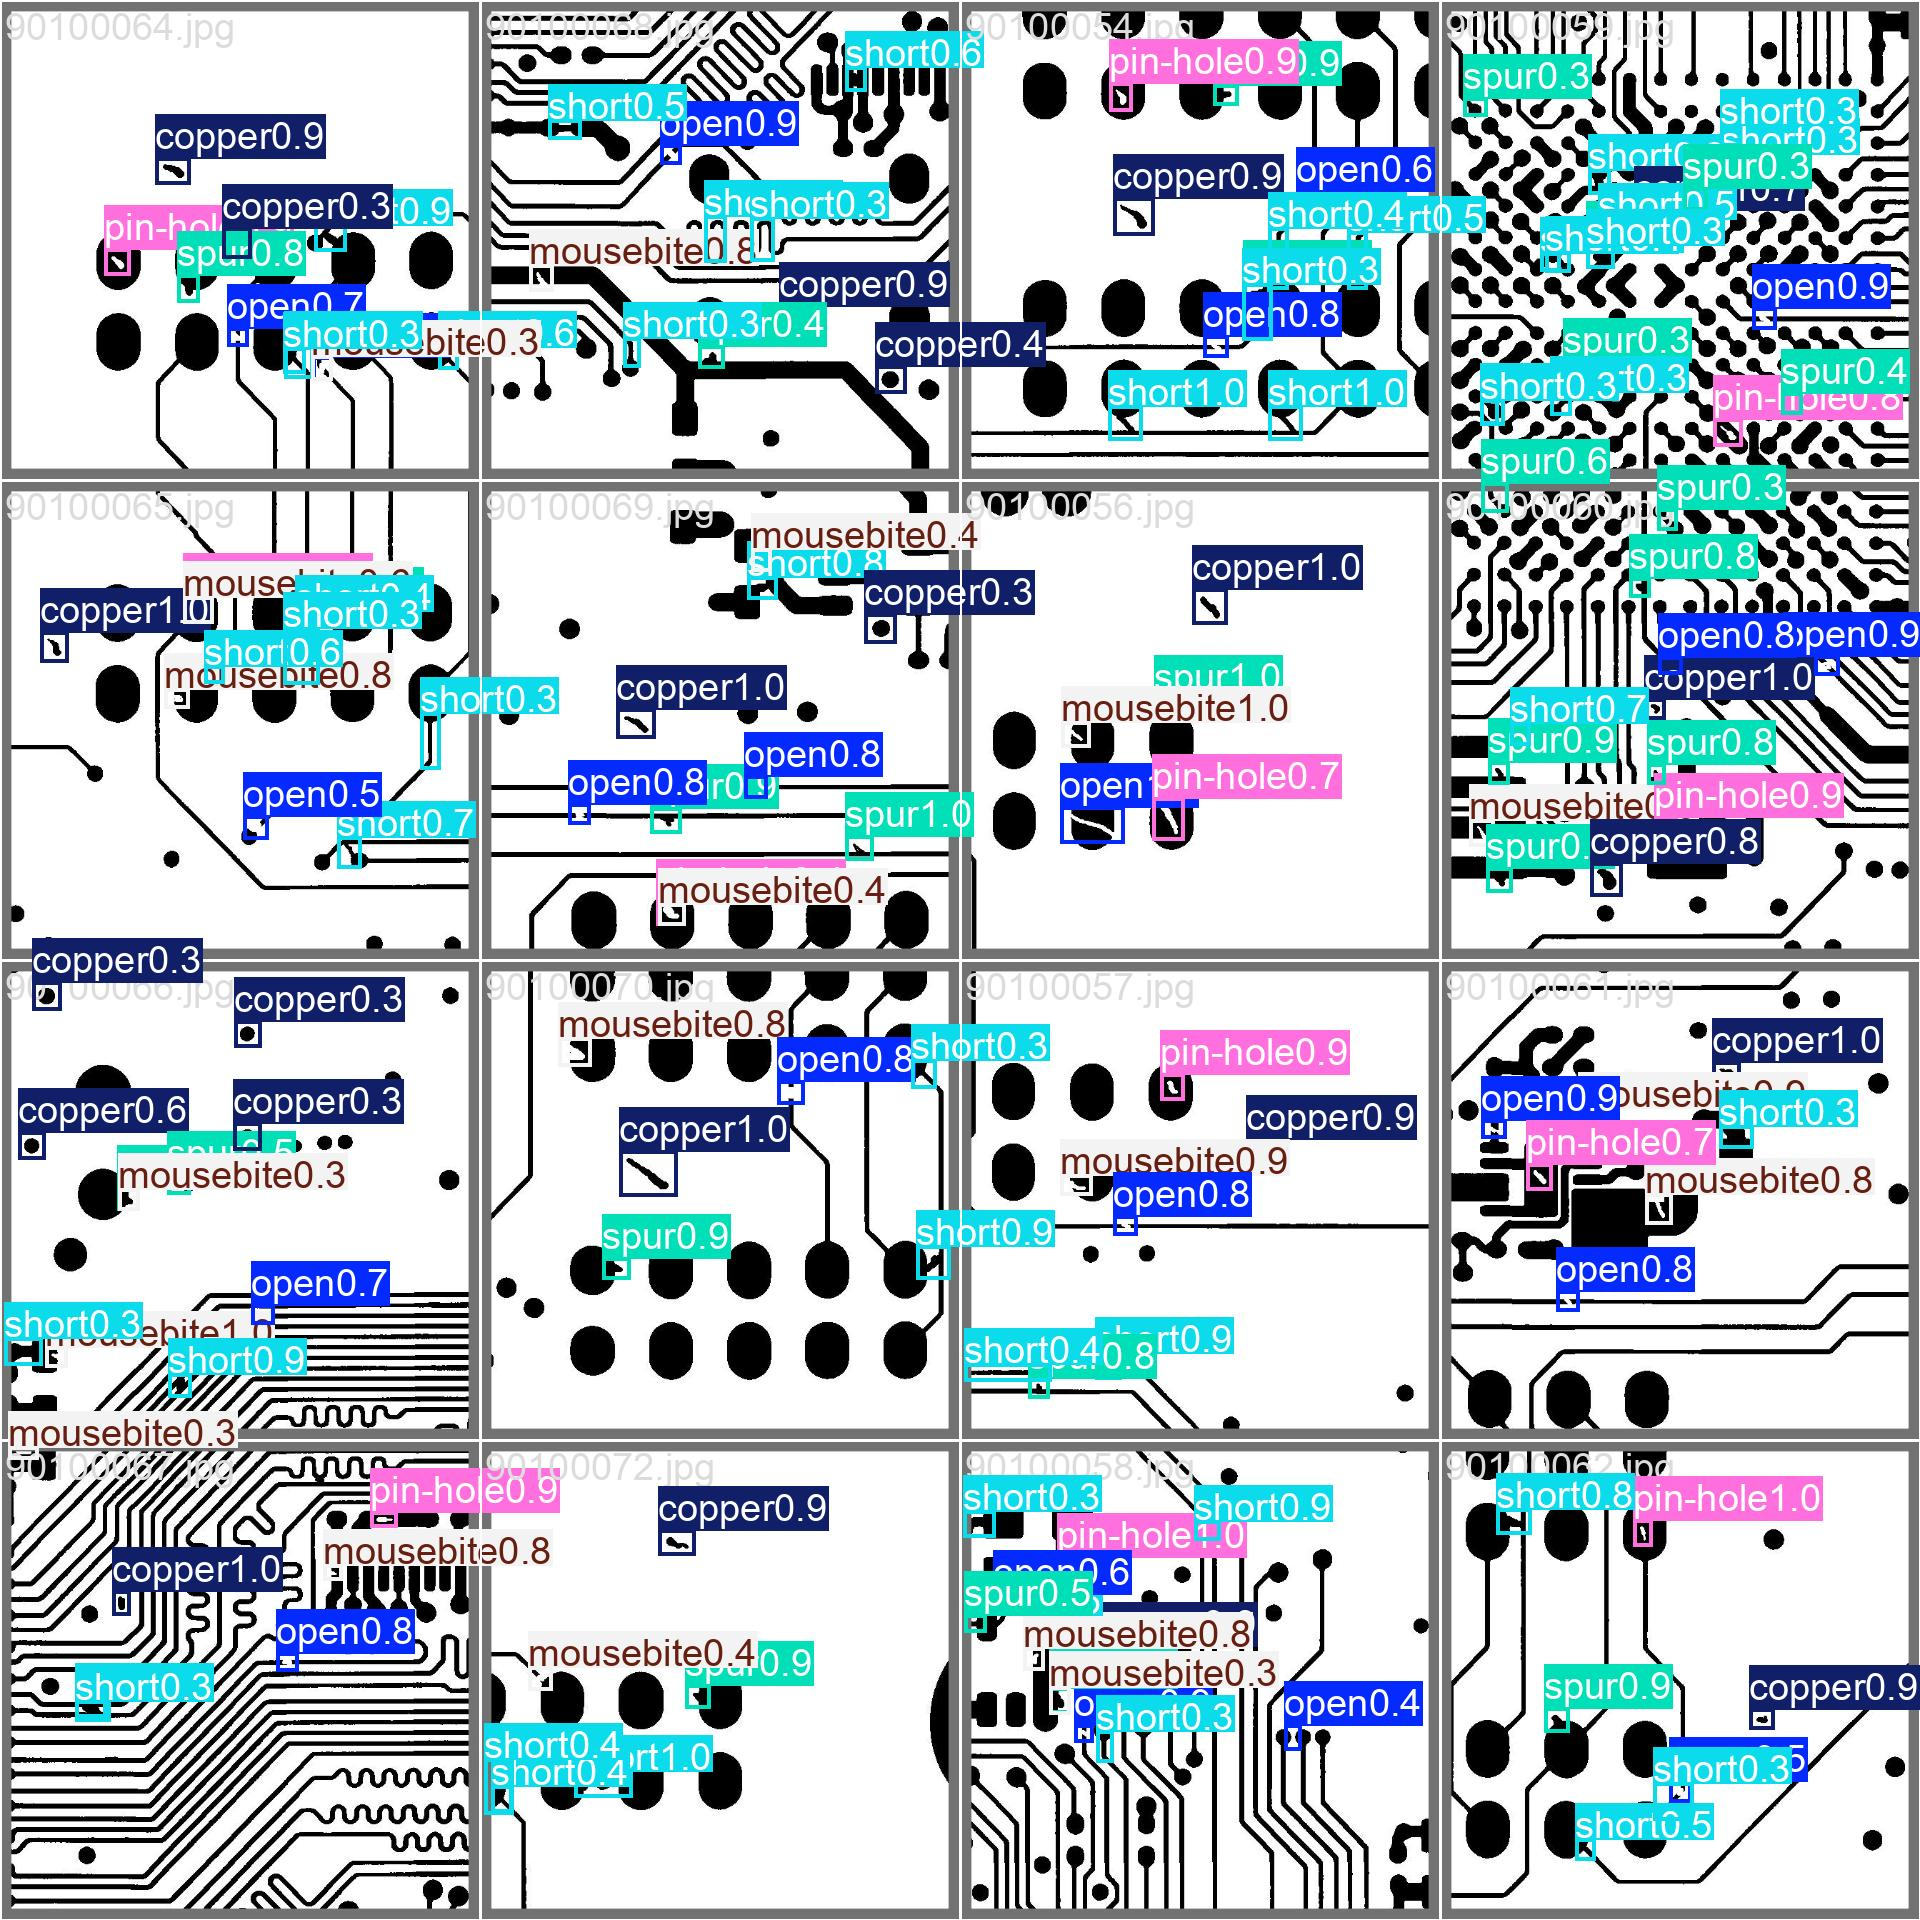

YOLO11s - Ejemplo de predicciones en test


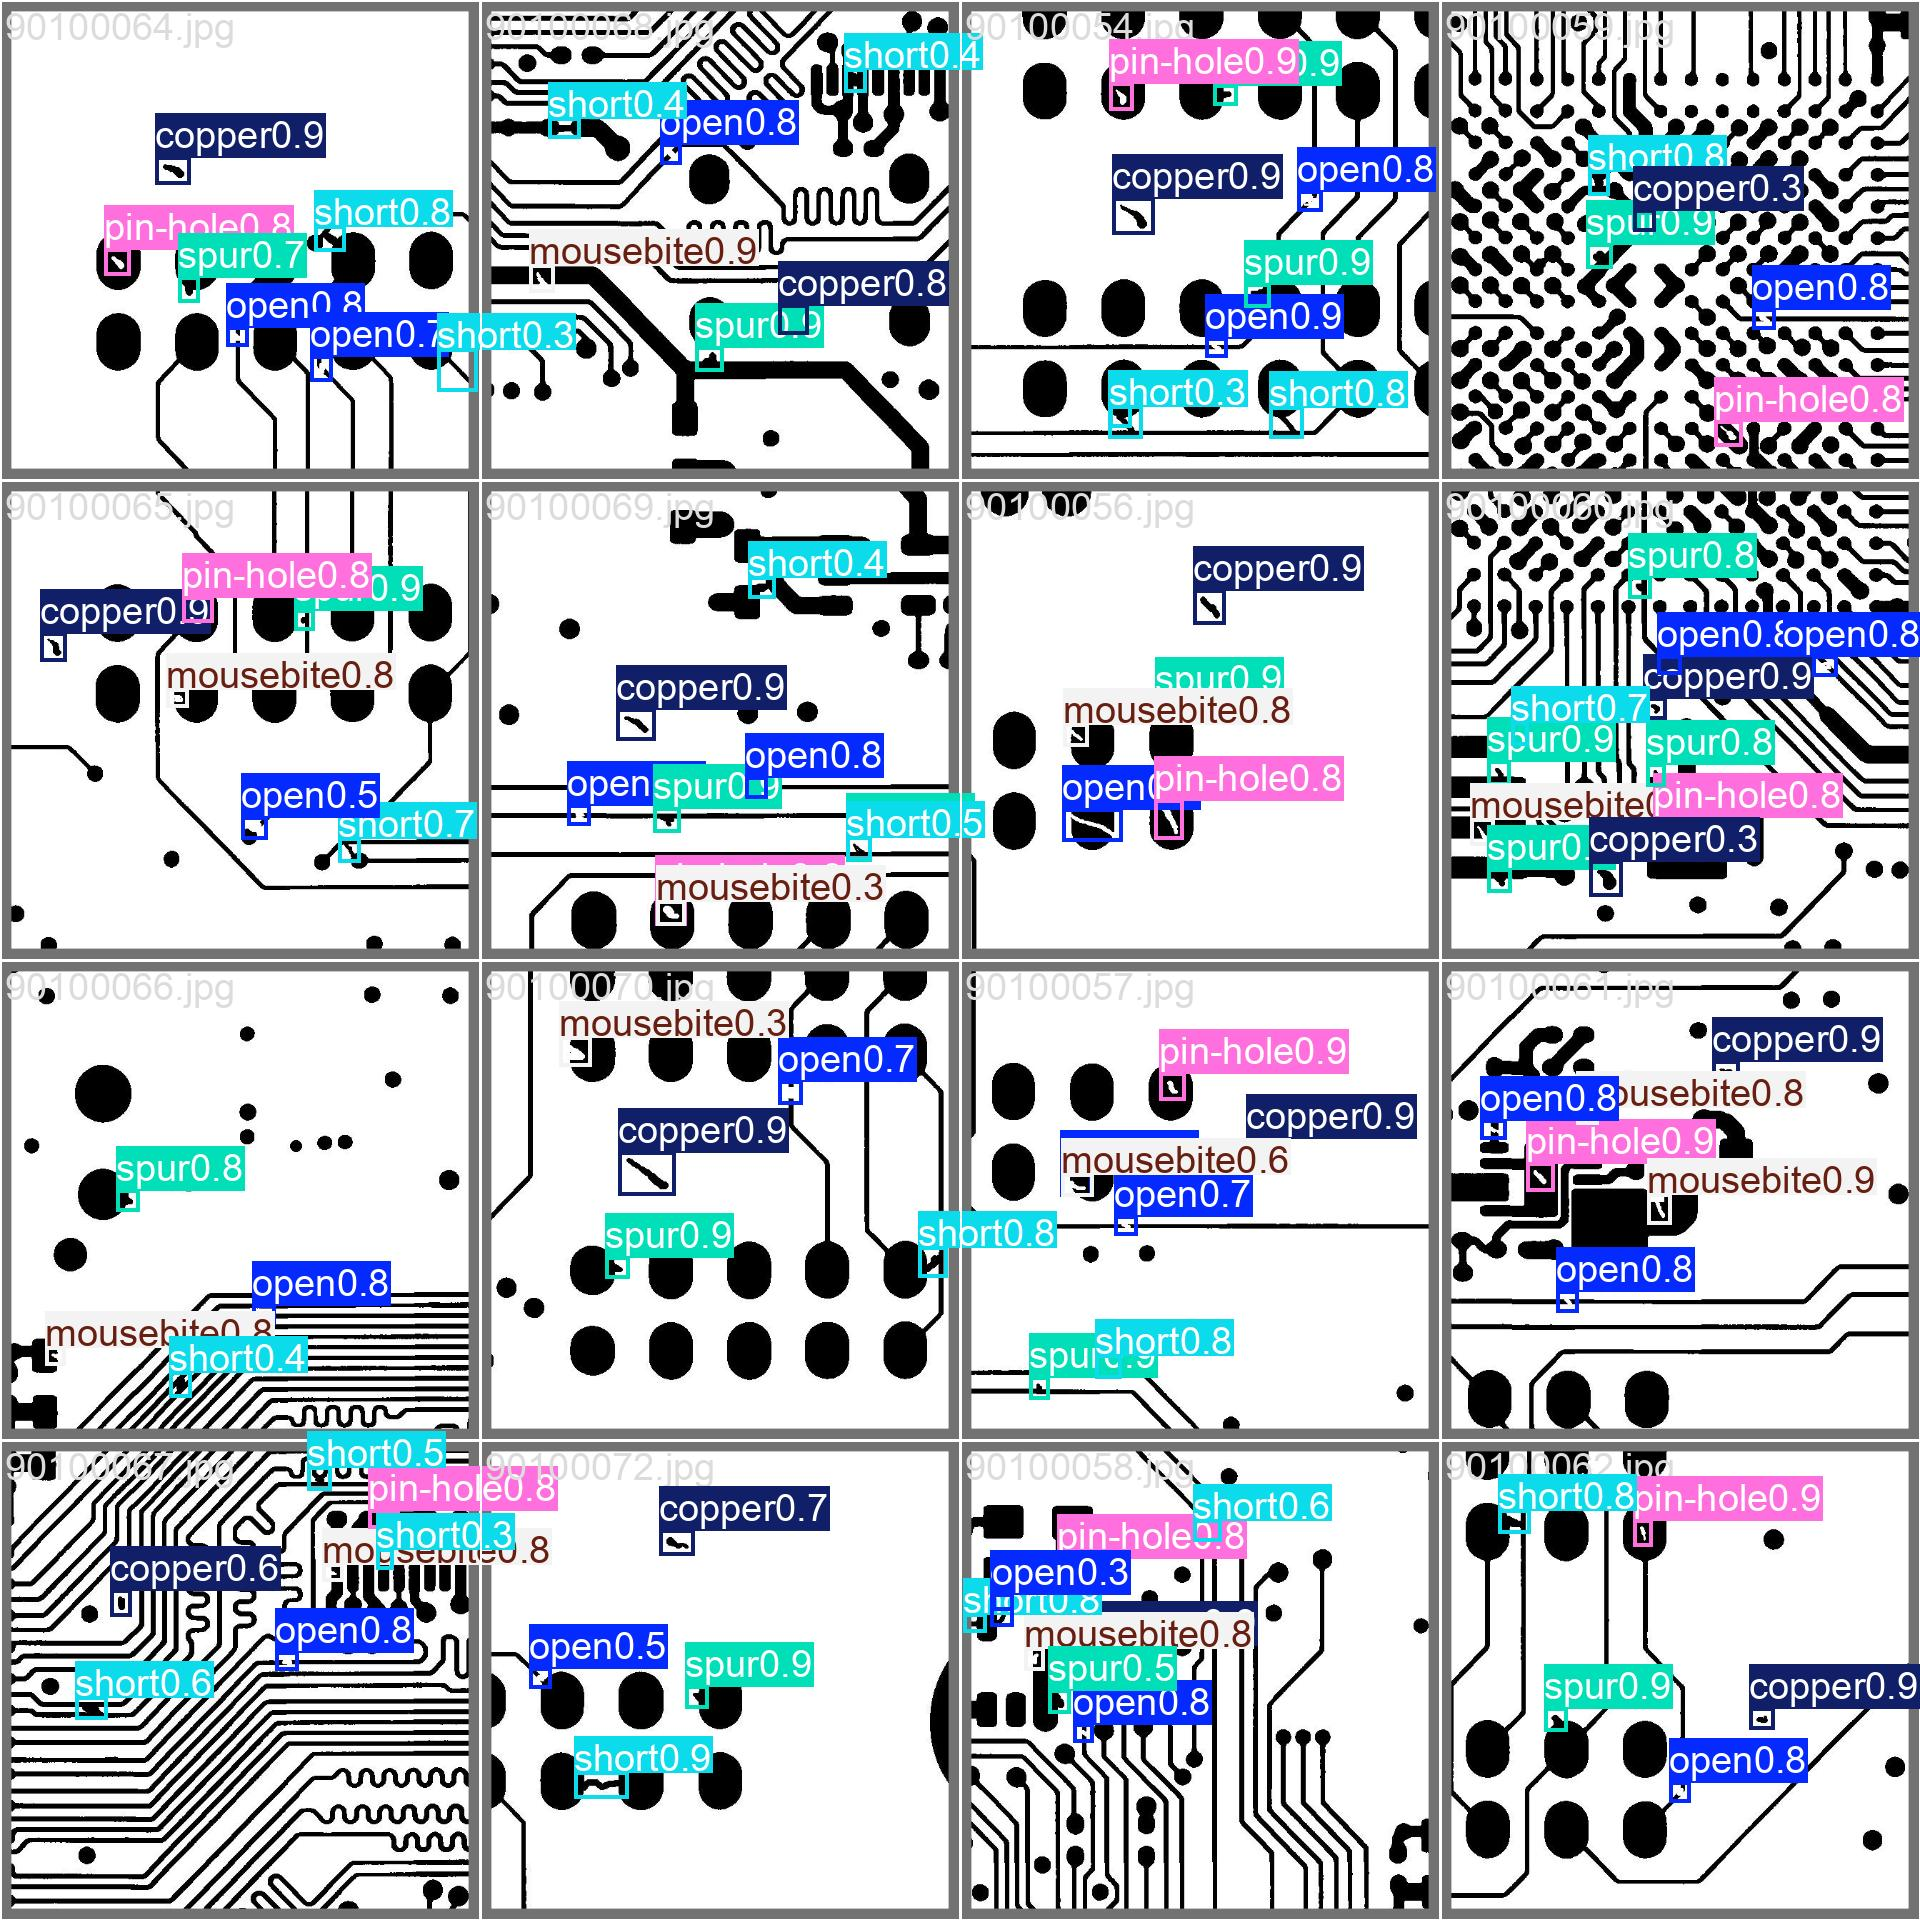

In [18]:
figure_files = {
    "YOLO11n - Ejemplo de predicciones en test": "yolo11n_test_val_batch0_pred.jpg",
    "YOLO11s - Ejemplo de predicciones en test": "yolo11s_test_val_batch0_pred.jpg",
}

for title, filename in figure_files.items():
    print(title)
    display(Image(filename=str(FIGURES_DIR / filename)))

### 6.1 Interpretación cualitativa

Los ejemplos visuales muestran que ambos modelos logran identificar múltiples defectos dentro de una misma imagen y ubicar las regiones afectadas mediante *bounding boxes*.

La inspección cualitativa resulta consistente con los resultados cuantitativos: tanto YOLO11 Nano como YOLO11 Small alcanzan un desempeño elevado, aunque pueden observarse diferencias puntuales en la confianza asignada, la localización de algunos defectos y la detección de clases más difíciles.

Este análisis también evidencia la complejidad del problema, dado que los defectos ocupan áreas reducidas de la imagen y en muchos casos aparecen varias anomalías simultáneamente dentro de una misma PCB.

## 7. Costo computacional

Además del desempeño predictivo, se analiza el costo computacional de cada variante de YOLO. Este aspecto resulta relevante porque una eventual aplicación práctica de inspección visual podría requerir tiempos de inferencia reducidos, menor consumo de recursos o ejecución sobre hardware limitado.

Ambos modelos fueron entrenados en Google Colab utilizando GPU Tesla T4. Se configuró un máximo de 50 épocas, aunque en ambos casos el entrenamiento finalizó antes por Early Stopping debido a la ausencia de mejoras durante 10 épocas consecutivas.

In [19]:
computational_cost = pd.DataFrame([
    {
        "model": "YOLO11n",
        "epochs_completed": 28,
        "best_epoch": 18,
        "training_time_min": 8.16,
        "parameters_millions": 2.58,
        "gflops": 6.3,
        "best_model_size_mb": 5.5,
        "inference_ms_per_image": 2.8,
        "postprocess_ms_per_image": 3.9,
    },
    {
        "model": "YOLO11s",
        "epochs_completed": 23,
        "best_epoch": 13,
        "training_time_min": 7.41,
        "parameters_millions": 9.42,
        "gflops": 21.3,
        "best_model_size_mb": 19.2,
        "inference_ms_per_image": 6.0,
        "postprocess_ms_per_image": 5.3,
    },
])

computational_cost

,model,epochs_completed,best_epoch,training_time_min,parameters_millions,gflops,best_model_size_mb,inference_ms_per_image,postprocess_ms_per_image
0,YOLO11n,28,18,8.16,2.58,6.3,5.5,2.8,3.9
1,YOLO11s,23,13,7.41,9.42,21.3,19.2,6.0,5.3


In [20]:
nano_cost = computational_cost[
    computational_cost["model"] == "YOLO11n"
].iloc[0]

small_cost = computational_cost[
    computational_cost["model"] == "YOLO11s"
].iloc[0]

cost_comparison = pd.DataFrame([
    {
        "metric": "Parámetros",
        "YOLO11n": nano_cost["parameters_millions"],
        "YOLO11s": small_cost["parameters_millions"],
        "unit": "millones",
        "relative_increase_%": (
            (small_cost["parameters_millions"] / nano_cost["parameters_millions"] - 1) * 100
        ),
    },
    {
        "metric": "GFLOPs",
        "YOLO11n": nano_cost["gflops"],
        "YOLO11s": small_cost["gflops"],
        "unit": "GFLOPs",
        "relative_increase_%": (
            (small_cost["gflops"] / nano_cost["gflops"] - 1) * 100
        ),
    },
    {
        "metric": "Tamaño best.pt",
        "YOLO11n": nano_cost["best_model_size_mb"],
        "YOLO11s": small_cost["best_model_size_mb"],
        "unit": "MB",
        "relative_increase_%": (
            (small_cost["best_model_size_mb"] / nano_cost["best_model_size_mb"] - 1) * 100
        ),
    },
    {
        "metric": "Inferencia",
        "YOLO11n": nano_cost["inference_ms_per_image"],
        "YOLO11s": small_cost["inference_ms_per_image"],
        "unit": "ms/img",
        "relative_increase_%": (
            (small_cost["inference_ms_per_image"] / nano_cost["inference_ms_per_image"] - 1) * 100
        ),
    },
])

cost_comparison["relative_increase_%"] = (
    cost_comparison["relative_increase_%"].round(2)
)

cost_comparison

,metric,YOLO11n,YOLO11s,unit,relative_increase_%
0,Parámetros,2.58,9.42,millones,265.12
1,GFLOPs,6.30,21.30,GFLOPs,238.10
2,Tamaño best.pt,5.50,19.20,MB,249.09
3,Inferencia,2.80,6.00,ms/img,114.29


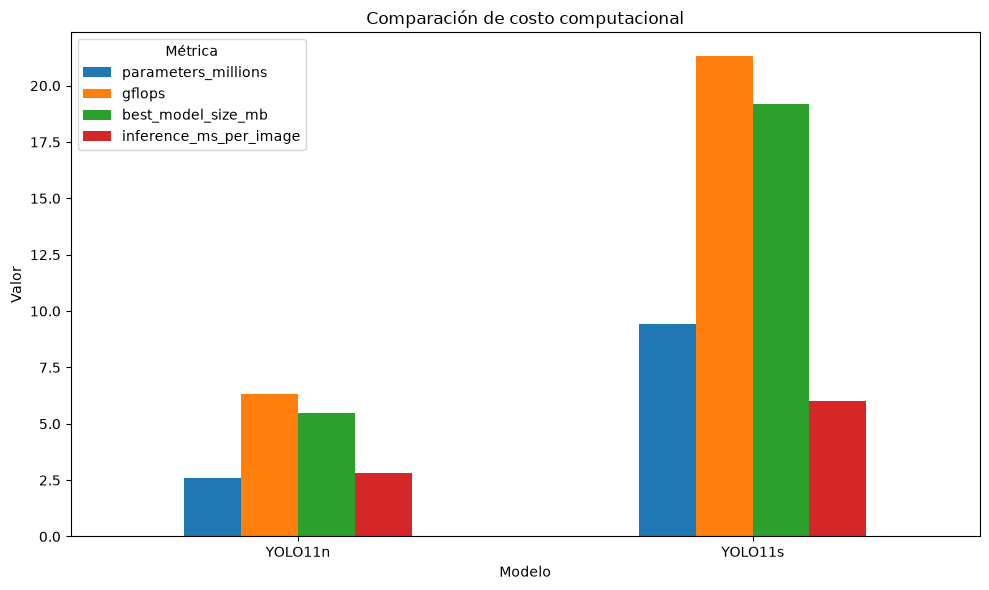

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_data = computational_cost.set_index("model")[
    [
        "parameters_millions",
        "gflops",
        "best_model_size_mb",
        "inference_ms_per_image",
    ]
]

plot_data.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Comparación de costo computacional")
ax.set_xlabel("Modelo")
ax.set_ylabel("Valor")
ax.legend(title="Métrica")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### 7.1 Interpretación del costo computacional

La comparación evidencia que YOLO11 Small presenta una complejidad computacional considerablemente mayor que YOLO11 Nano. Mientras que YOLO11 Nano posee aproximadamente 2,58 millones de parámetros y 6,3 GFLOPs, YOLO11 Small alcanza aproximadamente 9,42 millones de parámetros y 21,3 GFLOPs.

Esto implica que YOLO11 Small tiene alrededor de 3,65 veces más parámetros y 3,38 veces más GFLOPs que YOLO11 Nano. También presenta un tamaño de archivo mayor: el modelo `best.pt` pasa de aproximadamente 5,5 MB en YOLO11 Nano a 19,2 MB en YOLO11 Small.

En términos de inferencia, YOLO11 Nano registró aproximadamente 2,8 ms por imagen, mientras que YOLO11 Small registró aproximadamente 6,0 ms por imagen en el mismo entorno de evaluación. Por lo tanto, YOLO11 Small requiere más del doble de tiempo de inferencia por imagen.

Un aspecto particular es que el tiempo total de entrenamiento registrado fue levemente menor para YOLO11 Small que para YOLO11 Nano. Esto no implica que Small sea computacionalmente más liviano, sino que el entrenamiento finalizó antes por Early Stopping: YOLO11 Small completó 23 épocas, mientras que YOLO11 Nano completó 28. Por este motivo, el tiempo total de entrenamiento no debe interpretarse de forma aislada, sino junto con la cantidad de épocas, parámetros, GFLOPs y tiempo de inferencia.

En síntesis, YOLO11 Small obtuvo mejor desempeño predictivo, especialmente en mAP@50:95, pero con un costo computacional claramente superior. YOLO11 Nano, por su parte, ofrece un desempeño competitivo con un modelo mucho más liviano, por lo que podría ser una alternativa atractiva en escenarios donde la velocidad de inferencia, el tamaño del modelo o las restricciones de hardware sean factores prioritarios.

Considerando simultáneamente desempeño y costo computacional, YOLO11 Small puede considerarse el mejor modelo desde una perspectiva de precisión predictiva, mientras que YOLO11 Nano representa una alternativa más eficiente. La elección entre ambos dependería del contexto de aplicación: si se prioriza maximizar la calidad de detección y localización, Small resulta preferible; si se prioriza velocidad, bajo peso del modelo o despliegue en hardware limitado, Nano podría ser más conveniente.

## 8. Discusión final

Los resultados obtenidos permiten comparar el desempeño de YOLO11 Nano y YOLO11 Small para la detección automática de defectos en placas de circuito impreso.

A nivel global, YOLO11 Small supera a YOLO11 Nano en todas las métricas evaluadas sobre el conjunto de prueba. La mejora más relevante se observa en mAP@50:95, donde YOLO11 Small alcanza 72,33 % frente a 68,56 % de YOLO11 Nano. Esta diferencia sugiere que el modelo Small no sólo logra detectar correctamente los defectos, sino que también mejora la calidad de localización de las *bounding boxes* bajo criterios de IoU más exigentes.

Sin embargo, el análisis por clase muestra que la mejora no es completamente uniforme. YOLO11 Small mejora el mAP@50:95 en todas las categorías, pero el comportamiento de precision y recall varía según el tipo de defecto. En particular, Small mejora fuertemente el recall de la clase `open` y la precision de la clase `short`, mientras que en otras clases presenta leves disminuciones de recall o precision. Esto demuestra que las métricas globales deben complementarse con análisis por categoría, especialmente en problemas de inspección de calidad donde cada tipo de defecto puede tener distinta criticidad.

Las matrices de confusión y las curvas Precision-Recall confirman que ambos modelos presentan un desempeño elevado, aunque también muestran que algunas clases, como `short`, son más desafiantes. Este comportamiento puede estar asociado a la similitud visual entre ciertos defectos, el tamaño reducido de las regiones afectadas y la presencia de múltiples anomalías dentro de una misma imagen.

Desde el punto de vista computacional, YOLO11 Small presenta un costo significativamente mayor. Posee aproximadamente 9,42 millones de parámetros frente a 2,58 millones de YOLO11 Nano, 21,3 GFLOPs frente a 6,3 GFLOPs y un tamaño de archivo de 19,2 MB frente a 5,5 MB. Además, el tiempo de inferencia por imagen fue aproximadamente 6,0 ms para Small y 2,8 ms para Nano. Por lo tanto, la mejora de desempeño de YOLO11 Small se obtiene a costa de un modelo más pesado y más demandante.

En función de estos resultados, YOLO11 Small puede considerarse el modelo con mejor desempeño predictivo general, mientras que YOLO11 Nano representa una alternativa más eficiente y liviana. La elección entre ambos dependería del contexto de aplicación. Si el objetivo principal es maximizar la calidad de detección y localización, YOLO11 Small resulta preferible. En cambio, si se prioriza velocidad, bajo consumo de recursos o despliegue en hardware limitado, YOLO11 Nano podría ser una opción más conveniente.

Finalmente, debe considerarse que el trabajo fue desarrollado sobre un dataset público de PCB y no sobre imágenes propias de un entorno productivo real. Por lo tanto, los resultados obtenidos constituyen una validación experimental del enfoque, pero no garantizan directamente el mismo desempeño en condiciones reales de producción. Para una futura aplicación industrial sería necesario construir un dataset propio, incorporar variabilidad de iluminación, cámaras, tipos de placa y defectos específicos, y evaluar el desempeño del modelo en condiciones operativas reales.

## 9. Conclusiones

El proyecto permitió implementar un pipeline completo de detección automática de defectos en PCB utilizando modelos YOLO.

Las principales conclusiones son:

- Se preparó el dataset DeepPCB para entrenamiento con YOLO, convirtiendo sus anotaciones originales al formato requerido por Ultralytics.
- Se entrenaron y evaluaron dos variantes de modelo, YOLO11 Nano y YOLO11 Small, mediante *fine-tuning* a partir de pesos preentrenados.
- Ambos modelos alcanzaron un desempeño elevado sobre el conjunto de prueba, lo que confirma la viabilidad del enfoque para la detección automática de defectos en PCB.
- YOLO11 Small obtuvo el mejor desempeño global, con una precision de 93,90 %, recall de 91,43 %, mAP@50 de 96,19 % y mAP@50:95 de 72,33 %.
- YOLO11 Nano también obtuvo resultados competitivos, con una precision de 92,25 %, recall de 90,68 %, mAP@50 de 95,38 % y mAP@50:95 de 68,56 %.
- La mayor diferencia entre modelos se observó en mAP@50:95, donde YOLO11 Small superó a YOLO11 Nano por aproximadamente 3,77 puntos porcentuales.
- El análisis por clase mostró que `short`, `open` y `mousebite` presentan mayores desafíos relativos.
- La comparación computacional evidenció que YOLO11 Small mejora el desempeño, pero a costa de mayor cantidad de parámetros, mayor tamaño de modelo, más GFLOPs y mayor tiempo de inferencia.
- En consecuencia, YOLO11 Small se identifica como la mejor alternativa si se prioriza desempeño predictivo, mientras que YOLO11 Nano puede ser preferible si se prioriza eficiencia computacional.

Como trabajo futuro, se propone evaluar el pipeline sobre imágenes propias de un entorno productivo, extender el problema hacia PCBAs con componentes electrónicos, analizar defectos como componentes faltantes, soldaduras defectuosas o componentes dañados, y estudiar estrategias de ajuste de umbrales por clase para optimizar el balance entre falsos positivos y falsos negativos.